# Analysis of the results from MentalManip dataset tests

MentalManip dataset separated in 2 in-context learning strategies studied for role playing (click links to jump to section):

- [Zero-shot results analysis](#Zero-shot)

- [Few-shot results analysis](#Few-shot)

- [Chain-of-Thoughts results analysis](#Chain-of-Thoughts)

In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
from datasets import load_dataset
import pandas as pd
from data_loader import load_mentalmanip_dataset

## Loading the MentalManip dataset

dataset_2 = load_dataset("audreyeleven/MentalManip", "mentalmanip_maj")
data_2 = dataset_2["train"]
df_2 = data_2.to_pandas()

sample_sizes_manip = {1: 250, 0: 250}
sample_sizes_examples_manip = {1: 5, 0: 5}
max_len_examples = 1000

sample_mentalmanip, sample_examples_mentalmanip = load_mentalmanip_dataset(
    df_2, 
    sample_sizes_manip, 
    sample_sizes_examples_manip, 
    max_len_examples,
    random_state=42,
    random_state_examples=0,
    )

Some datasets params were ignored: ['license']. Make sure to use only valid params for the dataset builder and to have a up-to-date version of the `datasets` library.


# Zero-shot
### Analysis results zero-shot - manipulation detection

In [3]:
from typing import Literal
from analysis_tools import (
    load_and_merge_profiles
    )
from cases.manipulation_case import manipulation_case


ALLOWED_MODELS = {"4o_mini", "4.1_mini"}

## Set the model you want to study here
model = "4.1_mini"

if model not in ALLOWED_MODELS:
    raise ValueError(f"Invalid model: {model}. Must be one of {ALLOWED_MODELS}")
if model == "4o_mini":
    model_foldername = "openai_4o_mini"
elif model == "4.1_mini":
    model_foldername = "openai_4.1_mini"

merged_df_zero_shot = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/zero_shot/classic/results_manipulation_zero_shot_prompt_short_binary.csv",
    role_playing_glob_pattern=f"results/{model_foldername}/zero_shot/role_playing_ethnics/*/results_manipulation_zero_shot_prompt_short_binary.csv",
    sample_df=sample_mentalmanip,
    case=manipulation_case
)

=== Found 60 profile result files.
=== Merged DataFrame ready with columns:
 ['sample_id', 'true_label', 'base_pred', 'technique', 'vulnerability', 'profile1', 'profile2', 'profile3', 'profile4', 'profile5', 'profile6', 'profile7', 'profile8', 'profile9', 'profile10', 'profile11', 'profile12', 'profile13', 'profile14', 'profile15', 'profile16', 'profile17', 'profile18', 'profile19', 'profile20', 'profile21', 'profile22', 'profile23', 'profile24', 'profile25', 'profile26', 'profile27', 'profile28', 'profile29', 'profile30', 'profile31', 'profile32', 'profile33', 'profile34', 'profile35', 'profile36', 'profile37', 'profile38', 'profile39', 'profile40', 'profile41', 'profile42', 'profile43', 'profile44', 'profile45', 'profile46', 'profile47', 'profile48', 'profile49', 'profile50', 'profile51', 'profile52', 'profile53', 'profile54', 'profile55', 'profile56', 'profile57', 'profile58', 'profile59', 'profile60', 'prompt_tokens__base_pred', 'completion_tokens__base_pred', 'tokens_used__base_pr

Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')


=== DEMOGRAPHIC ACCURACY DIFFERENCES ===
[INFO] Profiles covered by metadata: 60/60

COMPREHENSIVE DEMOGRAPHIC ACCURACY DIFFERENCES ANALYSIS

EXECUTIVE SUMMARY
----------------------------------------
Total Comparisons Performed: 32
Significant Differences Found: 6
Statistical Significance Rate: 18.8%

LARGEST EFFECT SIZES
----------------------------------------
 1. age_age.age_4_vs_age.age_5          Effect Size: -1.599 (Large)
 2. age_age.age_3_vs_age.age_4          Effect Size:  1.400 (Large)
 3. age_age.age_2_vs_age.age_4          Effect Size:  1.261 (Large)
 4. asian_vs_latine                     Effect Size:  1.069 (Large)
 5. age_age.age_1_vs_age.age_5          Effect Size: -0.992 (Large)

DETAILED SIGNIFICANT RESULTS
[NON-SIGNIFICANT]     men_vs_women                        | Man: 0.669 | Woman: 0.668
         Δ = +0.001 | p = 0.573 | d = 0.149


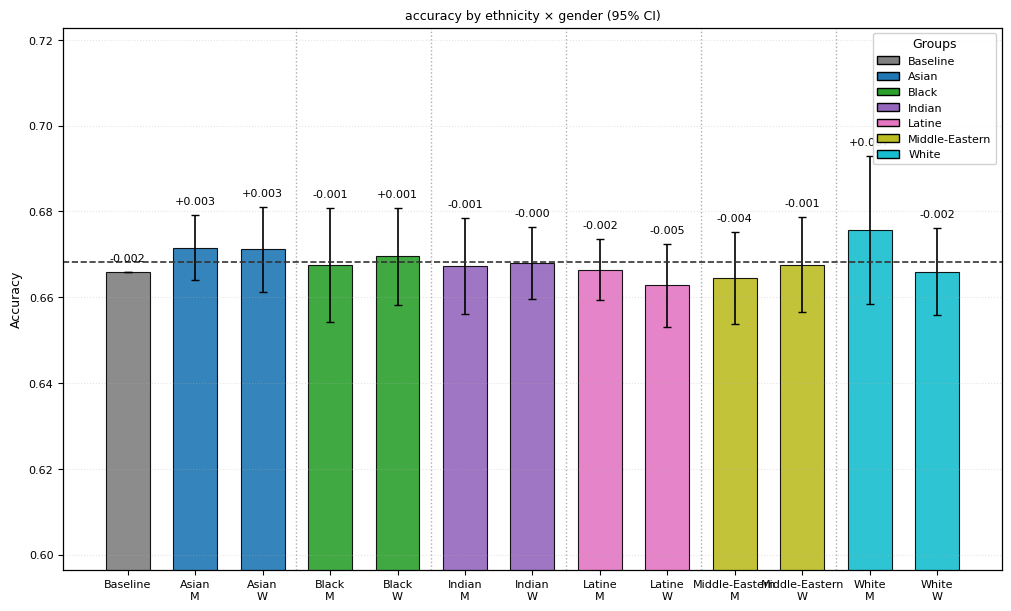

In [4]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS
from cases.manipulation_case import manipulation_case

results_preliminary_zero_shot = run_full_preliminary_analysis(merged_df_zero_shot, case=manipulation_case, df=sample_mentalmanip, person_set=PERSON_ETHNICS)

COMPREHENSIVE TIER 1 BIAS ANALYSIS PIPELINE
Group keys: None
Dataset shape: (500, 309)
Auto-detecting available traits from PersonSet...
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')
Dataset shape: (500, 309)
Found category values in technique: ['Accusation', 'Accusation,Evasion', 'Accusation,Persuasion or Seduction', 'Accusation,Rationalization', 'Brandishing Anger', 'Brandishing Anger,Accusation', 'Brandishing Anger,Persuasion or Seduction', 'Denial', 'Denial,Accusation', 'Denial,Feigning Innocence', 'Evasion', 'Evasion,Accusation', 'Evasion,Intimidation', 'Feigning Innocence', 'Feigning Innocence,Evasion', 'Intimidation', 'Intimidation,Accusation', 'Intimidation,Brandishing Anger', 'Intimidation,Persuasion or Seduction', 'Persuasion or Seduction', 'Persuasion or Seduction,Accusation', 'Persuasion or Seduction,Intimidation', 'Persuasion or Seduction,Rationalization', 'Persuasion or Seduction,Shaming

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_1.py:685: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


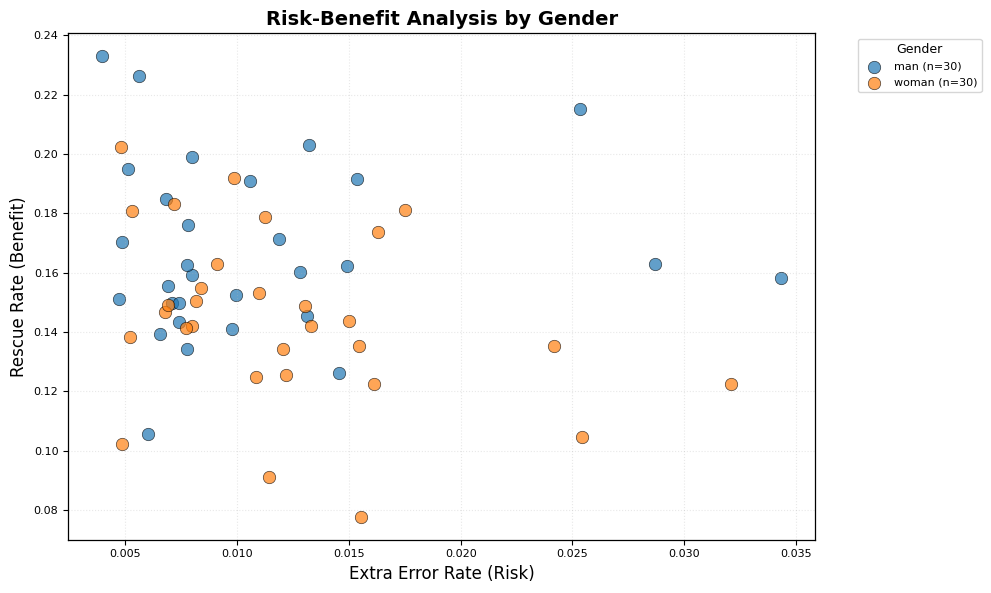


Creating risk-benefit plot for ethnicity...
  ethnicity levels: ['white', 'black', 'asian', 'latine', 'middle_eastern', 'indian']


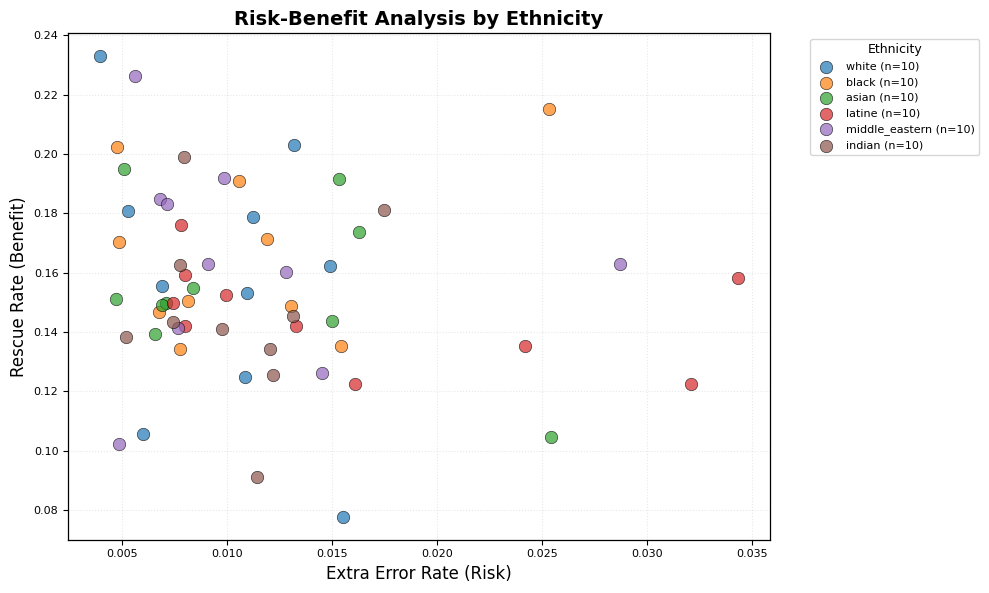


Creating risk-benefit plot for age...

Creating Pareto frontier analysis...


/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_1.py:755: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


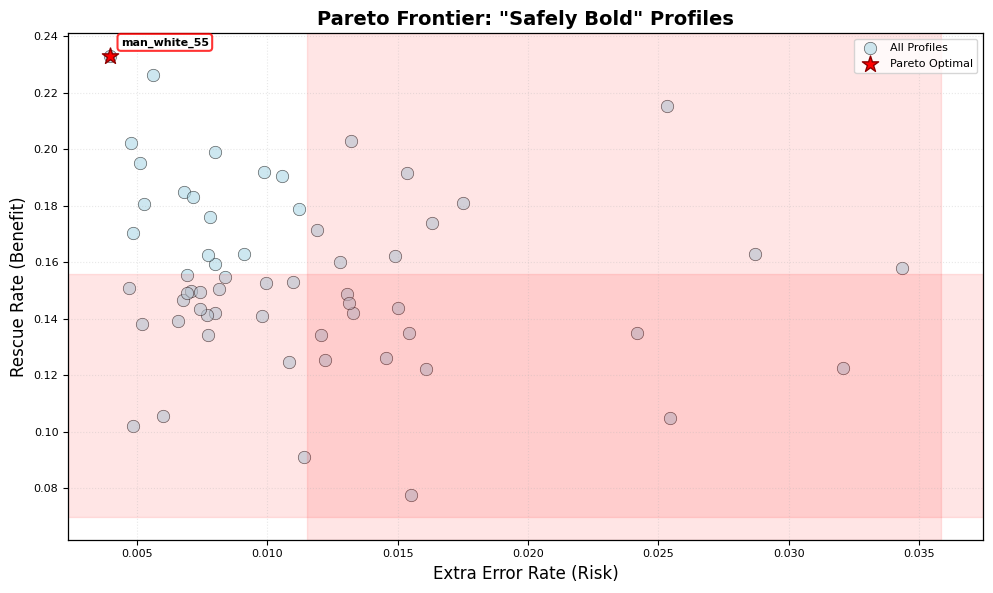


PARETO FRONTIER ANALYSIS RESULTS

Pareto Optimal Profiles (1 found):
  man_white_55 (profile5)
    Rescue Rate: 0.233, Extra Error Rate: 0.004
    Total Rescued: 78, Total Extra Errors: 48

Risk-Benefit Statistics:
  Total profiles analyzed: 60
  Average rescue rate: 0.156
  Average extra error rate: 0.012
  Best rescue rate: 0.233
  Lowest extra error rate: 0.004

Profile Archetypes:
  Safest Profile: man_white_55 (profile5)
    Extra Error Rate: 0.004
  Most Beneficial Profile: man_white_55 (profile5)
    Rescue Rate: 0.233

Demographic Composition of Pareto Optimal Profiles:
  Gender:
    man: 1 (100.0%)
  Ethnicity:
    white: 1 (100.0%)
  Age:
=== Pareto frontier analysis completed successfully

STEP 3: EFFECT SIZE CALCULATIONS
CALCULATING ANOVA-BASED EFFECT SIZES

MAIN EFFECTS FROM ANOVA
----------------------------------------

Processing significant main effect: age
  accuracy - 20 vs 25: d = -0.468 (small)
  accuracy - 20 vs 35: d = -0.567 (medium)
  accuracy - 20 vs 45: d = 

In [5]:
from analysis_1 import run_full_tier1_analysis

result_tier1_zero_shot = run_full_tier1_analysis(merged_df_zero_shot, case=manipulation_case, person_set=PERSON_ETHNICS)

EXECUTING COMPREHENSIVE TIER 2 ANALYSIS PIPELINE
Group keys: ('gender', 'ethnicity')
Dataset shape: (500, 309)
Category columns from CaseConfig: ['technique', 'vulnerability']
Using provided group keys: ('gender', 'ethnicity')
Dataset shape: (500, 309)

=== Running Step 1: Ensemble by Trait Analysis...
ENSEMBLE BY TRAIT ANALYSIS - PERSONSET VERSION
Group keys: ('gender', 'ethnicity')
Building trait groups with keys: ('gender', 'ethnicity')
Found 60 profile columns
Discovered trait values:
  gender: ['man', 'woman']
  ethnicity: ['asian', 'black', 'indian', 'latine', 'middle_eastern', 'white']
Created 12 trait groups:
  man_asian: 5 profiles
  man_black: 5 profiles
  man_indian: 5 profiles
  man_latine: 5 profiles
  man_middle_eastern: 5 profiles
  man_white: 5 profiles
  woman_asian: 5 profiles
  woman_black: 5 profiles
  woman_indian: 5 profiles
  woman_latine: 5 profiles
  woman_middle_eastern: 5 profiles
  woman_white: 5 profiles
Baseline accuracy: 0.6660

Ensemble Performance by Tr

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_2.py:1173: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


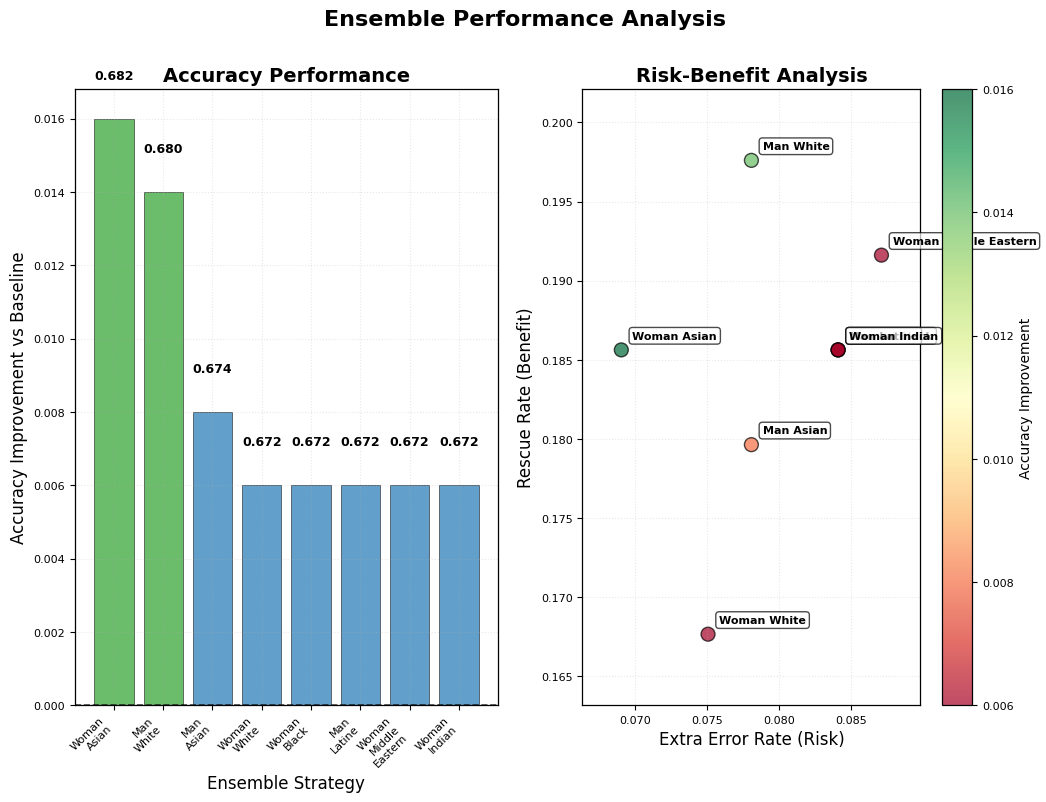

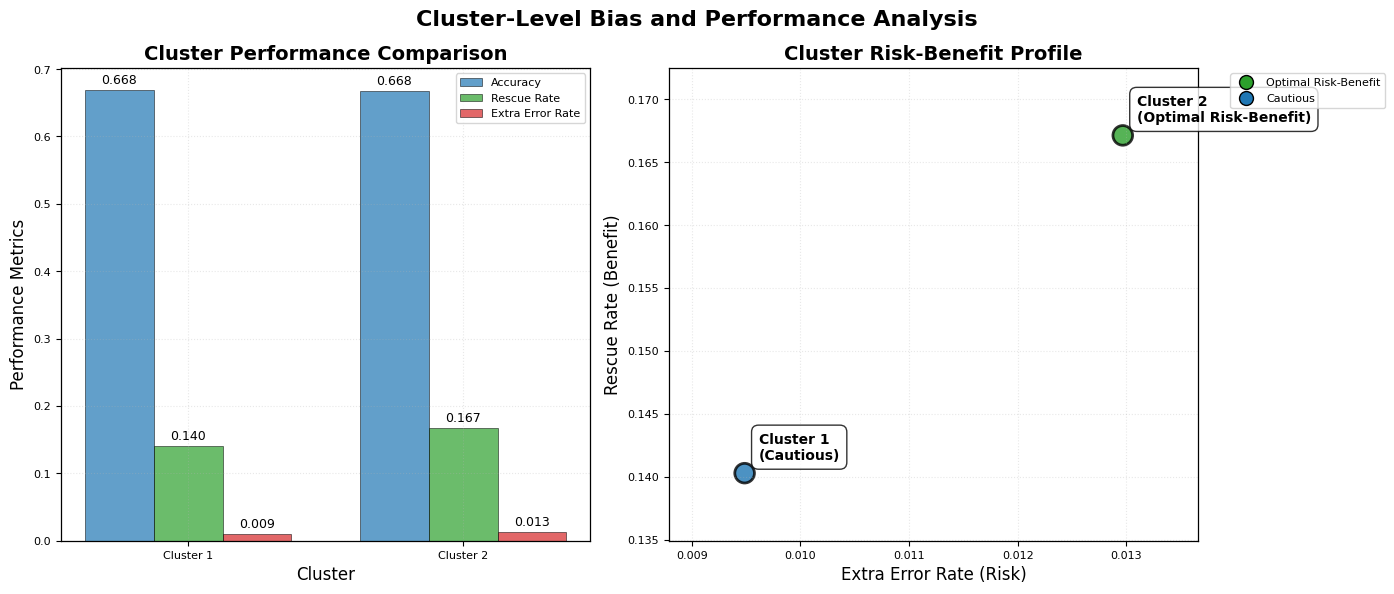

4. System-Level Recommendations...


/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_2.py:1383: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


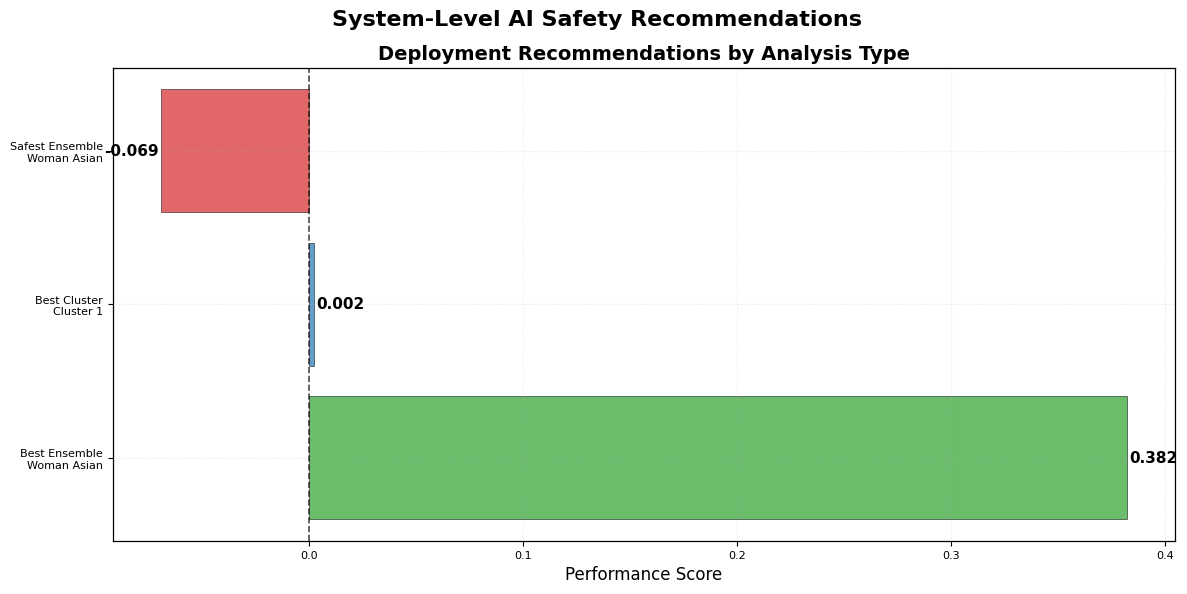


Completed! Created 2 visualizations.
SUCCESS: Visualizations created successfully

COMPREHENSIVE TIER 2 EXECUTIVE SUMMARY
   • Best Overall Ensemble: woman_asian
   • Best Cluster: cluster_1
   • Cognitive style analysis skipped: No cognitive style data found


In [6]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS

results_tier2_zero_shot = run_full_tier2_analysis(
    merged_df=merged_df_zero_shot,
    person_set=PERSON_ETHNICS,
    case=manipulation_case,
    group_keys=("gender", "ethnicity"))


EXECUTING TIER 3 ANALYSIS PIPELINE
Auto-detecting available traits from PersonSet...
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')
Cross-validation folds: 5

=== Running Consistency vs Boldness Analysis ===
CONSISTENCY vs BOLDNESS TRADEOFF ANALYSIS
Group keys for analysis: ('gender', 'ethnicity', 'age')
Found 60 valid profiles out of 60 total profile columns
=== Calculating consistency across 5 folds...
=== Calculating boldness metrics...
Found category values in technique: ['Accusation', 'Accusation,Evasion', 'Accusation,Persuasion or Seduction', 'Accusation,Rationalization', 'Brandishing Anger', 'Brandishing Anger,Accusation', 'Brandishing Anger,Persuasion or Seduction', 'Denial', 'Denial,Accusation', 'Denial,Feigning Innocence', 'Evasion', 'Evasion,Accusation', 'Evasion,Intimidation', 'Feigning Innocence', 'Feigning Innocence,Evasion', 'Intimidation', 'Intimidation,Accusation', 'Intimidation,Brandi

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:657: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:674: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:714: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:745: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


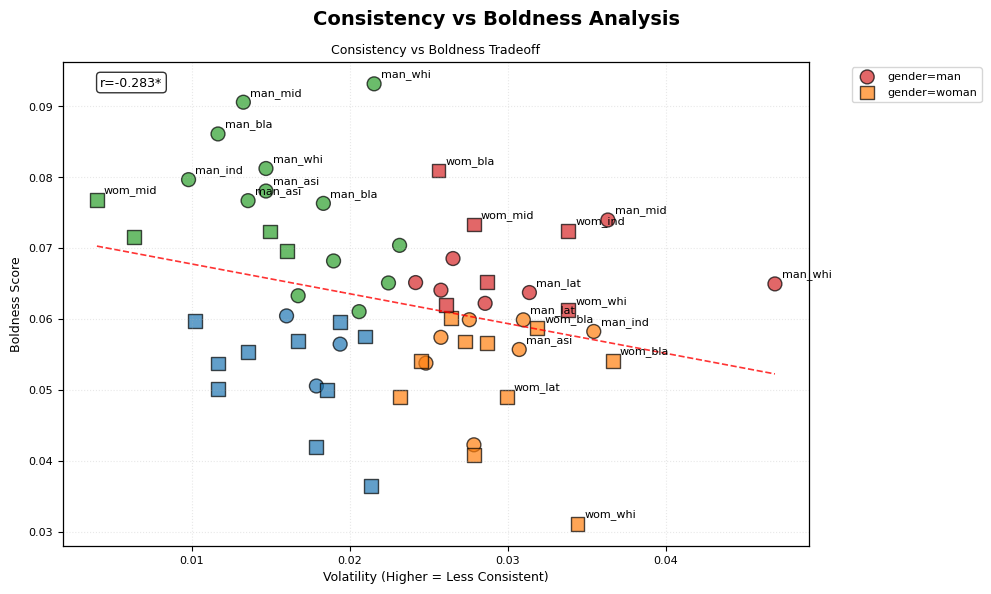

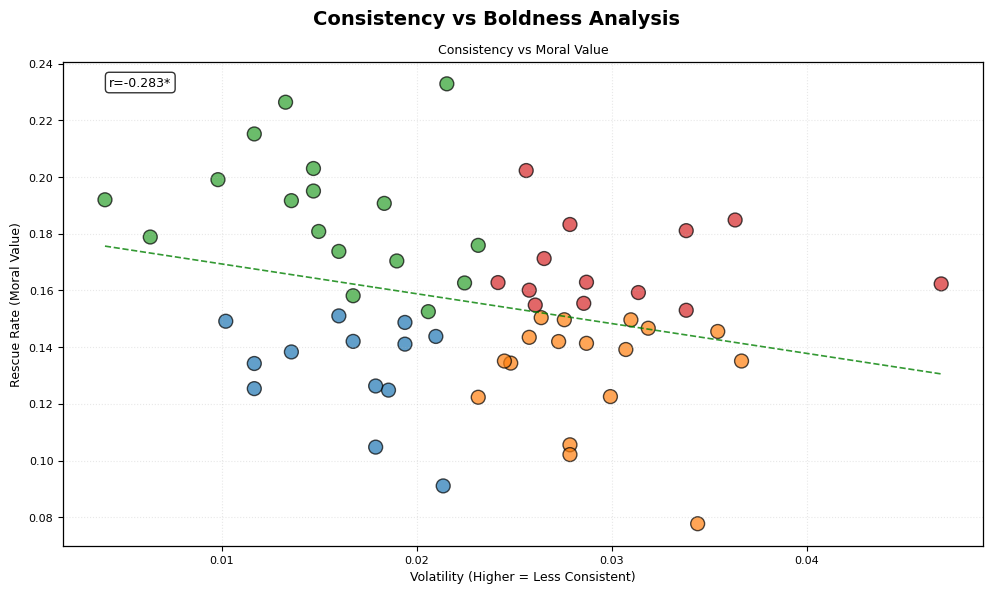

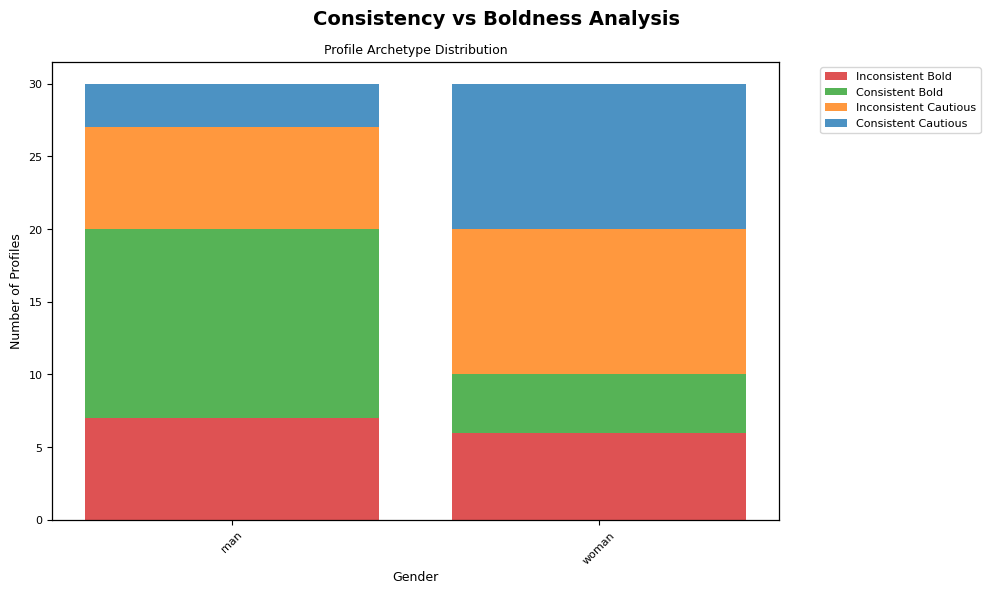

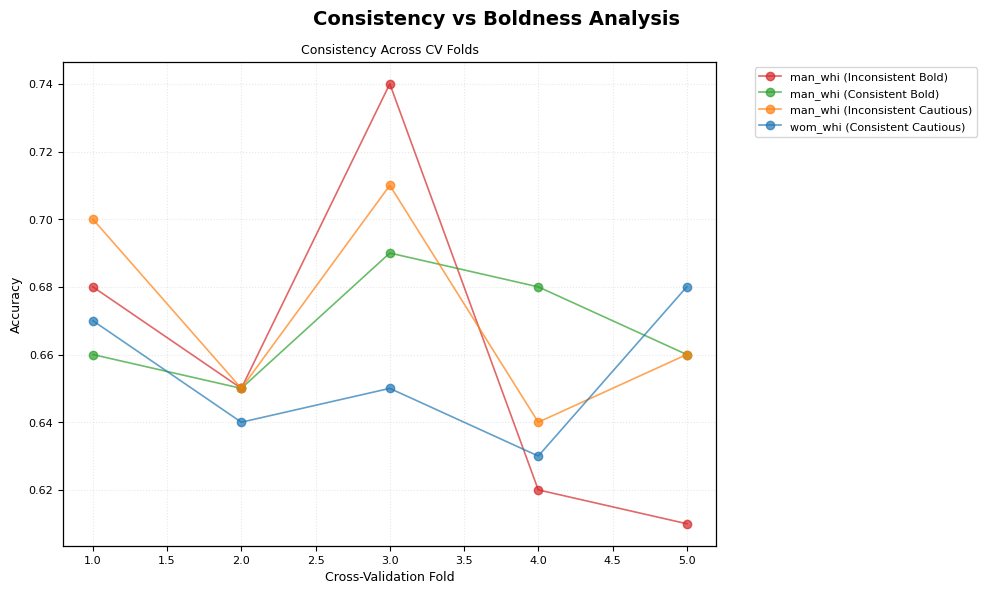

Consistency visualizations created successfully

=== Creating Causal Model Visualizations ===

TIER 3 THEORETICAL INTEGRATION

=== THEORETICAL INSIGHTS:
   - Consistent profiles match or outperform inconsistent ones in moral value
   - Implication: Consistency should be prioritized over boldness in AI systems
   - Evidence: Inconsistent rescue rate: 0.148 vs Consistent: 0.164
   - Strongest predictor of moral value (rescue): age_55
   - Strongest predictor of performance (accuracy): age_55
   - Bias assessment: 0 high, 0 moderate bias cases detected

THESIS-LEVEL CONCLUSIONS

METHODOLOGICAL ASSESSMENT
   - Data Quality: Good
   - Statistical Power: Adequate
   - Bias Detection Capability: Strong
   - Generalizability: Domain-specific
   - Profile coverage: 60 profiles
   - Trait coverage: 3 (gender, ethnicity, age)


/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:1463: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


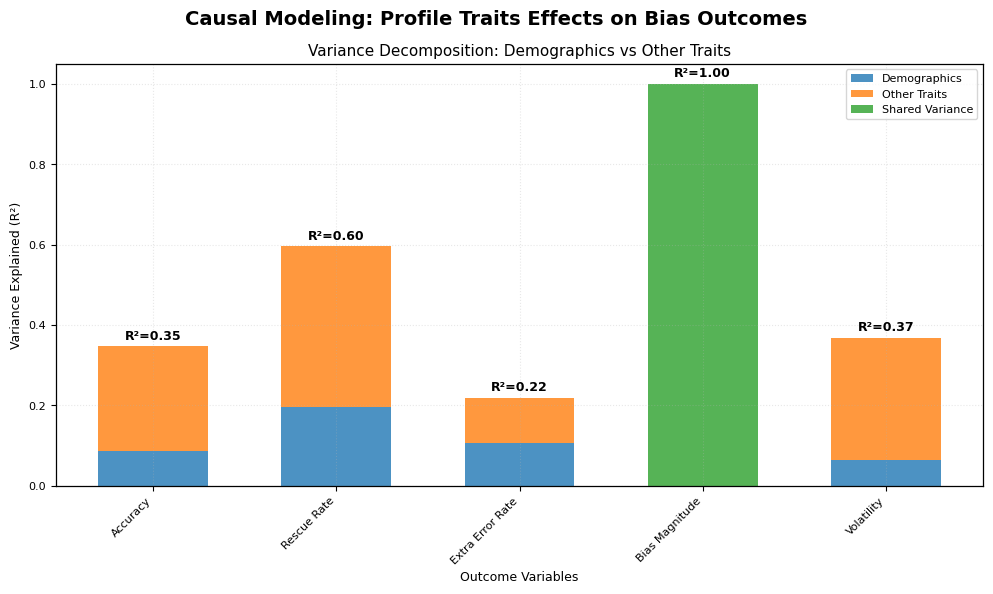

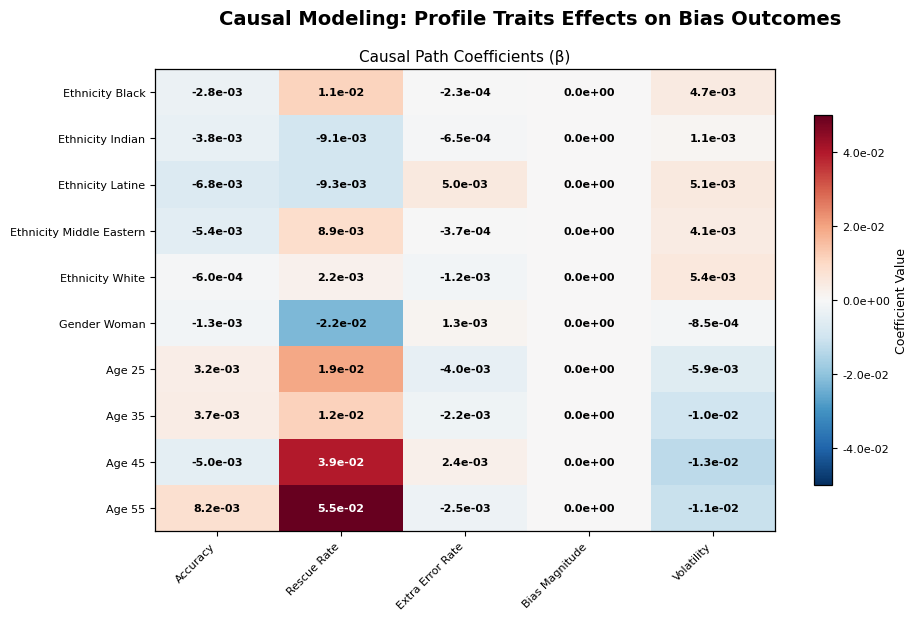

In [7]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS
from cases.manipulation_case import manipulation_case

result_tier3_zero_shot = run_full_tier3_analysis(merged_df_zero_shot, person_set=PERSON_ETHNICS, case=manipulation_case)




# Few-shot  
## Analysis results few-shot - manipulation detection

In [8]:
from analysis_tools import (
    load_and_merge_profiles
    )
from cases.manipulation_case import manipulation_case


ALLOWED_MODELS = {"4o_mini", "4.1_mini"}

## Set the model you want to study here
model = "4.1_mini"

if model not in ALLOWED_MODELS:
    raise ValueError(f"Invalid model: {model}. Must be one of {ALLOWED_MODELS}")
if model == "4o_mini":
    model_foldername = "openai_4o_mini"
elif model == "4.1_mini":
    model_foldername = "openai_4.1_mini"


merged_df_few_shot = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/few_shot/classic/results_manipulation_few_shot_prompt_short_3examples.csv",
    role_playing_glob_pattern= f"results/{model_foldername}/few_shot/role_playing_ethnics/*/results_manipulation_few_shot_prompt_short_3examples_binary.csv",
    sample_df=sample_mentalmanip,
    case=manipulation_case,
)

=== Found 60 profile result files.
=== Merged DataFrame ready with columns:
 ['sample_id', 'true_label', 'base_pred', 'technique', 'vulnerability', 'profile1', 'profile2', 'profile3', 'profile4', 'profile5', 'profile6', 'profile7', 'profile8', 'profile9', 'profile10', 'profile11', 'profile12', 'profile13', 'profile14', 'profile15', 'profile16', 'profile17', 'profile18', 'profile19', 'profile20', 'profile21', 'profile22', 'profile23', 'profile24', 'profile25', 'profile26', 'profile27', 'profile28', 'profile29', 'profile30', 'profile31', 'profile32', 'profile33', 'profile34', 'profile35', 'profile36', 'profile37', 'profile38', 'profile39', 'profile40', 'profile41', 'profile42', 'profile43', 'profile44', 'profile45', 'profile46', 'profile47', 'profile48', 'profile49', 'profile50', 'profile51', 'profile52', 'profile53', 'profile54', 'profile55', 'profile56', 'profile57', 'profile58', 'profile59', 'profile60', 'prompt_tokens__base_pred', 'completion_tokens__base_pred', 'tokens_used__base_pr

Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')


=== DEMOGRAPHIC ACCURACY DIFFERENCES ===
[INFO] Profiles covered by metadata: 60/60

COMPREHENSIVE DEMOGRAPHIC ACCURACY DIFFERENCES ANALYSIS

EXECUTIVE SUMMARY
----------------------------------------
Total Comparisons Performed: 32
Significant Differences Found: 5
Statistical Significance Rate: 15.6%

LARGEST EFFECT SIZES
----------------------------------------
 1. indian_vs_white                     Effect Size: -1.097 (Large)
 2. age_age.age_1_vs_age.age_2          Effect Size: -1.093 (Large)
 3. age_age.age_2_vs_age.age_3          Effect Size:  1.083 (Large)
 4. age_age.age_1_vs_age.age_5          Effect Size: -0.942 (Large)
 5. age_age.age_3_vs_age.age_5          Effect Size: -0.935 (Large)

DETAILED SIGNIFICANT RESULTS
[NON-SIGNIFICANT]     men_vs_women                        | Man: 0.673 | Woman: 0.670
         Δ = +0.003 | p = 0.163 | d = 0.371


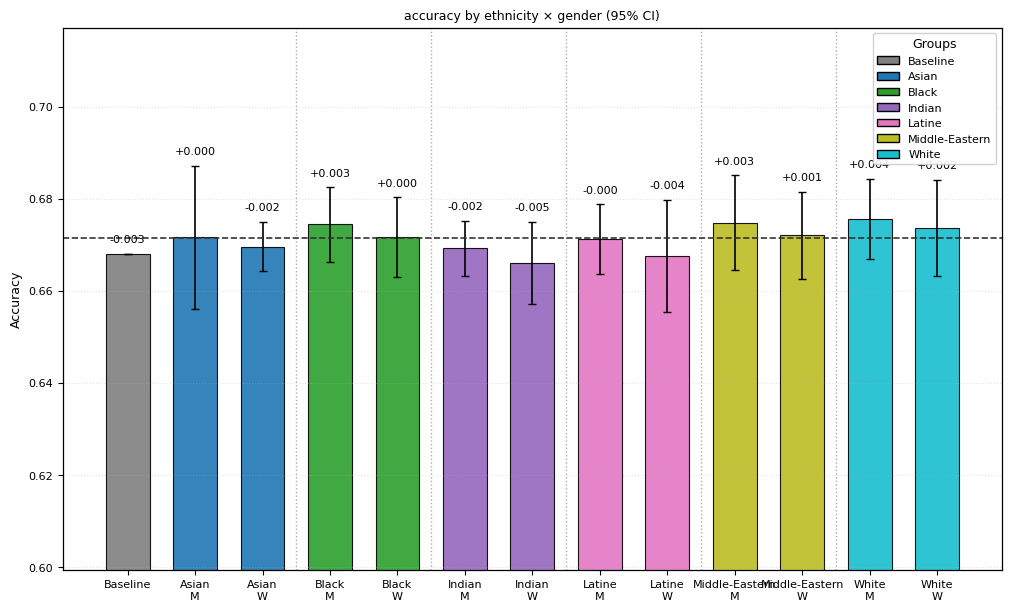

In [9]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS

results_preliminary_few_shot = run_full_preliminary_analysis(merged_df_few_shot, 
                                                    case=manipulation_case,
                                                    df=sample_mentalmanip, 
                                                    person_set=PERSON_ETHNICS)

COMPREHENSIVE TIER 1 BIAS ANALYSIS PIPELINE
Group keys: ('gender', 'ethnicity', 'age')
Dataset shape: (500, 309)
Using provided group keys: ('gender', 'ethnicity', 'age')
Dataset shape: (500, 309)
Found category values in technique: ['Accusation', 'Accusation,Evasion', 'Accusation,Persuasion or Seduction', 'Accusation,Rationalization', 'Brandishing Anger', 'Brandishing Anger,Accusation', 'Brandishing Anger,Persuasion or Seduction', 'Denial', 'Denial,Accusation', 'Denial,Feigning Innocence', 'Evasion', 'Evasion,Accusation', 'Evasion,Intimidation', 'Feigning Innocence', 'Feigning Innocence,Evasion', 'Intimidation', 'Intimidation,Accusation', 'Intimidation,Brandishing Anger', 'Intimidation,Persuasion or Seduction', 'Persuasion or Seduction', 'Persuasion or Seduction,Accusation', 'Persuasion or Seduction,Intimidation', 'Persuasion or Seduction,Rationalization', 'Persuasion or Seduction,Shaming or Belittlement', 'Playing Servant Role', 'Playing Servant Role,Accusation,Shaming or Belittlemen

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_1.py:685: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


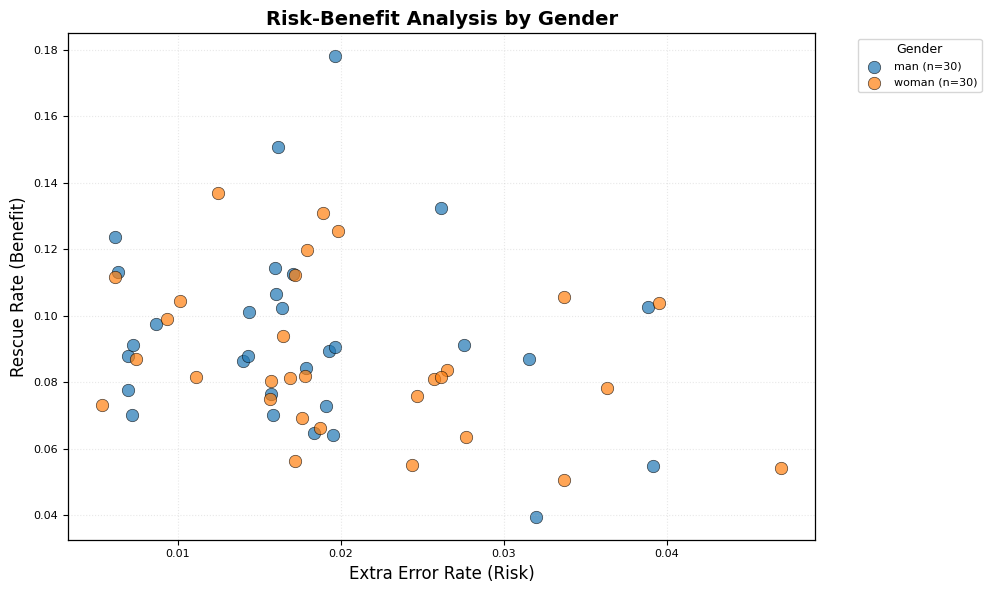


Creating risk-benefit plot for ethnicity...
  ethnicity levels: ['white', 'black', 'asian', 'latine', 'middle_eastern', 'indian']


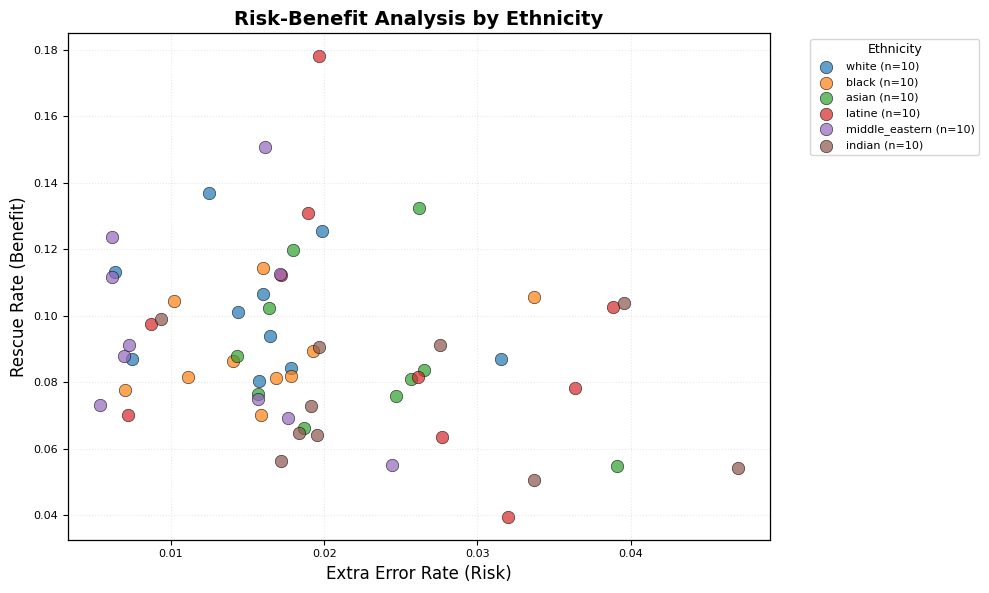


Creating risk-benefit plot for age...

Creating Pareto frontier analysis...


/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_1.py:755: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


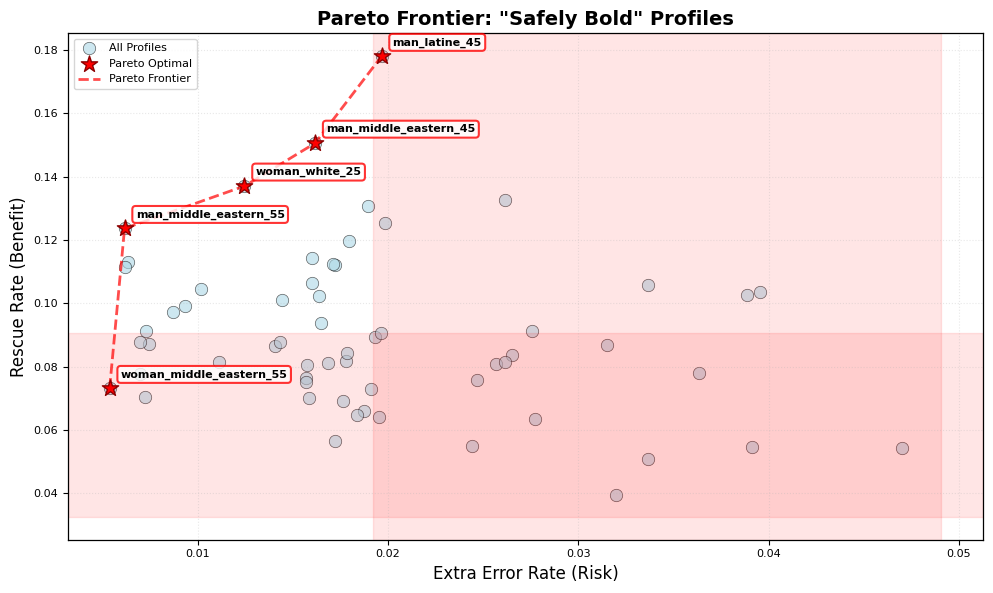


PARETO FRONTIER ANALYSIS RESULTS

Pareto Optimal Profiles (5 found):
  man_latine_45 (profile34)
    Rescue Rate: 0.178, Extra Error Rate: 0.020
    Total Rescued: 62, Total Extra Errors: 52
  man_middle_eastern_45 (profile44)
    Rescue Rate: 0.151, Extra Error Rate: 0.016
    Total Rescued: 56, Total Extra Errors: 42
  man_middle_eastern_55 (profile45)
    Rescue Rate: 0.124, Extra Error Rate: 0.006
    Total Rescued: 58, Total Extra Errors: 42
  woman_middle_eastern_55 (profile50)
    Rescue Rate: 0.073, Extra Error Rate: 0.005
    Total Rescued: 46, Total Extra Errors: 32
  woman_white_25 (profile7)
    Rescue Rate: 0.137, Extra Error Rate: 0.012
    Total Rescued: 58, Total Extra Errors: 48

Risk-Benefit Statistics:
  Total profiles analyzed: 60
  Average rescue rate: 0.091
  Average extra error rate: 0.019
  Best rescue rate: 0.178
  Lowest extra error rate: 0.005

Profile Archetypes:
  Safest Profile: woman_middle_eastern_55 (profile50)
    Extra Error Rate: 0.005
  Most Benefi

In [10]:
from analysis_1 import run_full_tier1_analysis

result_tier1_few_shot = run_full_tier1_analysis(merged_df_few_shot, 
                                       case=manipulation_case, 
                                       group_keys=("gender", "ethnicity", "age"), 
                                       person_set=PERSON_ETHNICS)

EXECUTING COMPREHENSIVE TIER 2 ANALYSIS PIPELINE
Group keys: ('gender', 'ethnicity')
Dataset shape: (500, 309)
Category columns from CaseConfig: ['technique', 'vulnerability']
Using provided group keys: ('gender', 'ethnicity')
Dataset shape: (500, 309)

=== Running Step 1: Ensemble by Trait Analysis...
ENSEMBLE BY TRAIT ANALYSIS - PERSONSET VERSION
Group keys: ('gender', 'ethnicity')
Building trait groups with keys: ('gender', 'ethnicity')
Found 60 profile columns
Discovered trait values:
  gender: ['man', 'woman']
  ethnicity: ['asian', 'black', 'indian', 'latine', 'middle_eastern', 'white']
Created 12 trait groups:
  man_asian: 5 profiles
  man_black: 5 profiles
  man_indian: 5 profiles
  man_latine: 5 profiles
  man_middle_eastern: 5 profiles
  man_white: 5 profiles
  woman_asian: 5 profiles
  woman_black: 5 profiles
  woman_indian: 5 profiles
  woman_latine: 5 profiles
  woman_middle_eastern: 5 profiles
  woman_white: 5 profiles
Baseline accuracy: 0.6680

Ensemble Performance by Tr

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_2.py:1173: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


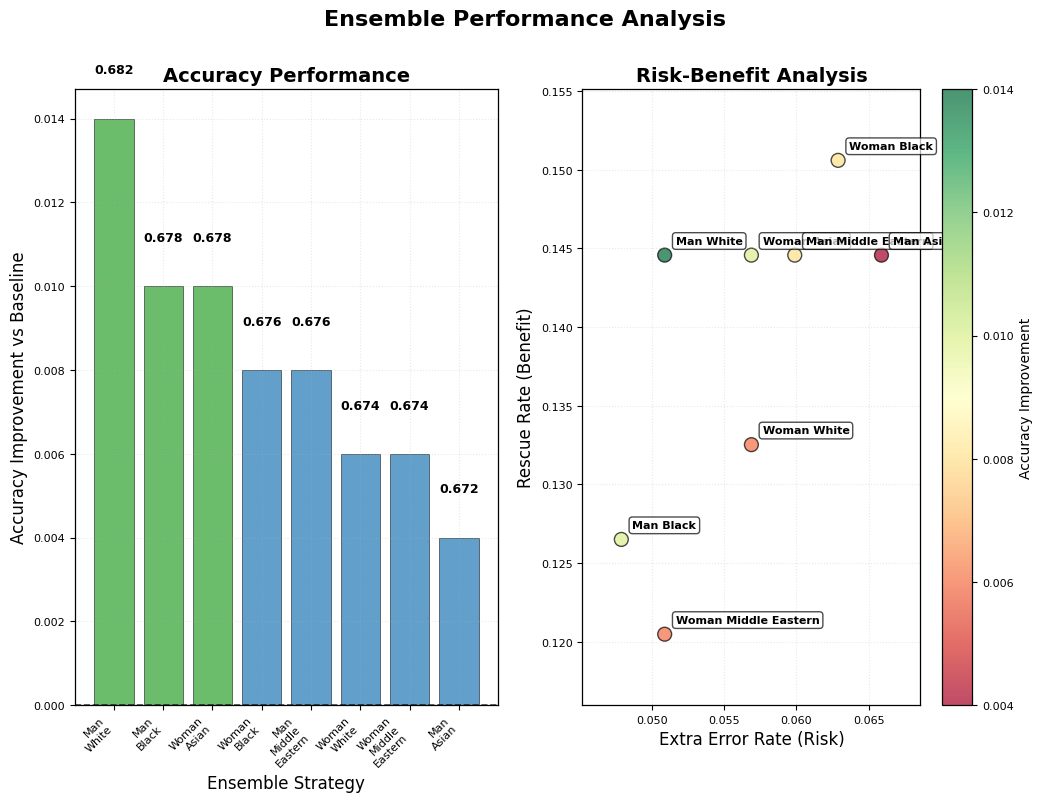

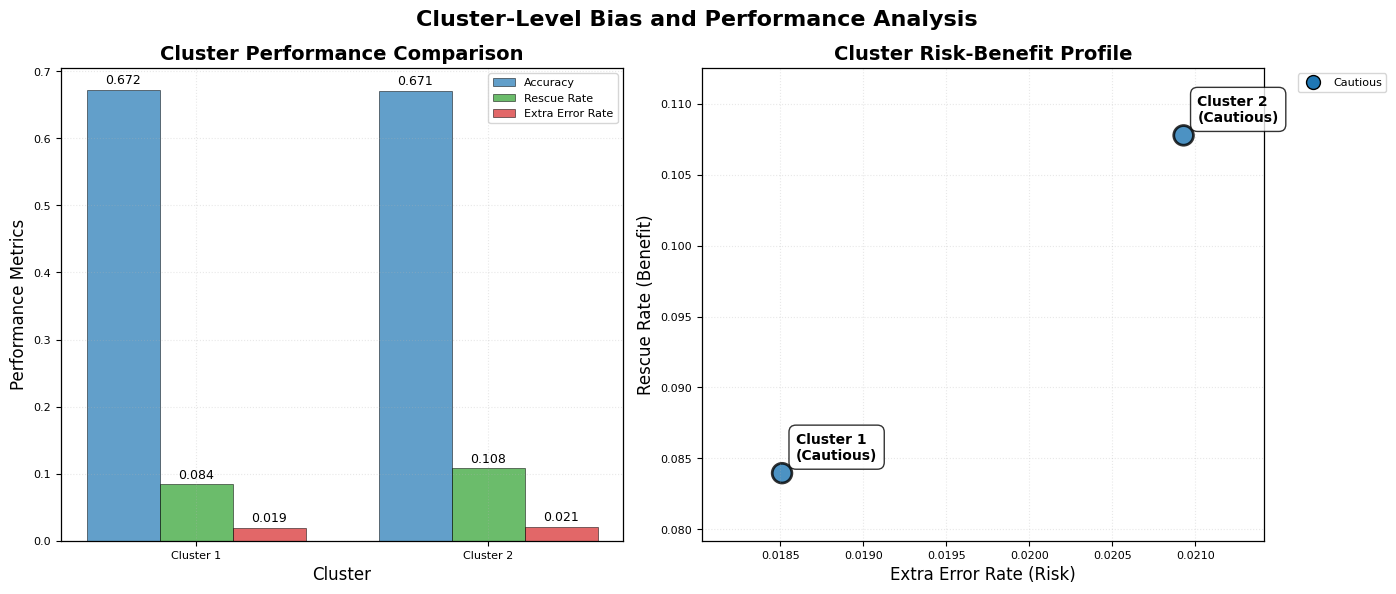

4. System-Level Recommendations...


/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_2.py:1383: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


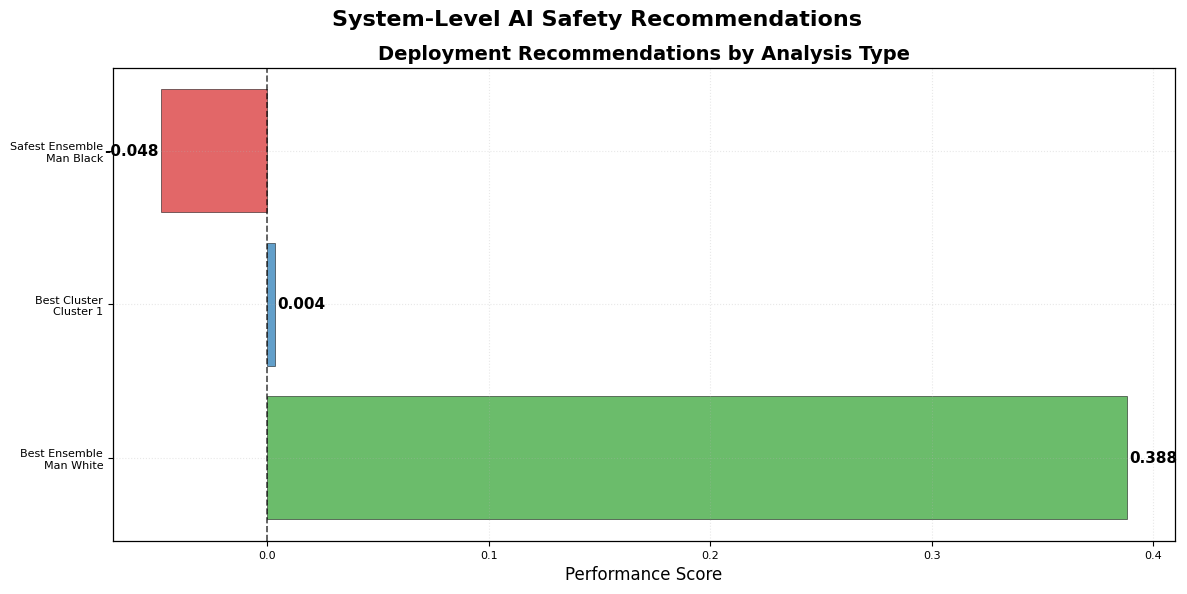


Completed! Created 2 visualizations.
SUCCESS: Visualizations created successfully

COMPREHENSIVE TIER 2 EXECUTIVE SUMMARY
   • Best Overall Ensemble: man_white
   • Best Cluster: cluster_1
   • Cognitive style analysis skipped: No cognitive style data found


In [11]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS
from cases.manipulation_case import manipulation_case

result_tier2_few_shot = run_full_tier2_analysis(
    merged_df=merged_df_few_shot,
    case=manipulation_case,
    person_set=PERSON_ETHNICS,
    group_keys=("gender", "ethnicity"))

EXECUTING TIER 3 ANALYSIS PIPELINE
Auto-detecting available traits from PersonSet...
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')
Cross-validation folds: 5

=== Running Consistency vs Boldness Analysis ===
CONSISTENCY vs BOLDNESS TRADEOFF ANALYSIS
Group keys for analysis: ('gender', 'ethnicity', 'age')
Found 60 valid profiles out of 60 total profile columns
=== Calculating consistency across 5 folds...
=== Calculating boldness metrics...
Found category values in technique: ['Accusation', 'Accusation,Evasion', 'Accusation,Persuasion or Seduction', 'Accusation,Rationalization', 'Brandishing Anger', 'Brandishing Anger,Accusation', 'Brandishing Anger,Persuasion or Seduction', 'Denial', 'Denial,Accusation', 'Denial,Feigning Innocence', 'Evasion', 'Evasion,Accusation', 'Evasion,Intimidation', 'Feigning Innocence', 'Feigning Innocence,Evasion', 'Intimidation', 'Intimidation,Accusation', 'Intimidation,Brandi

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:657: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:674: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:714: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:745: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


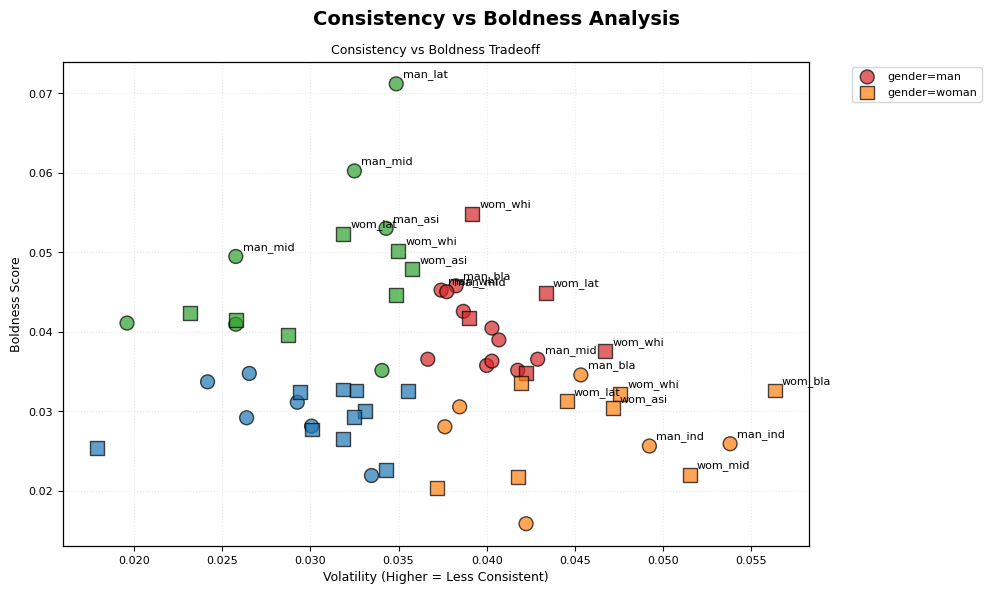

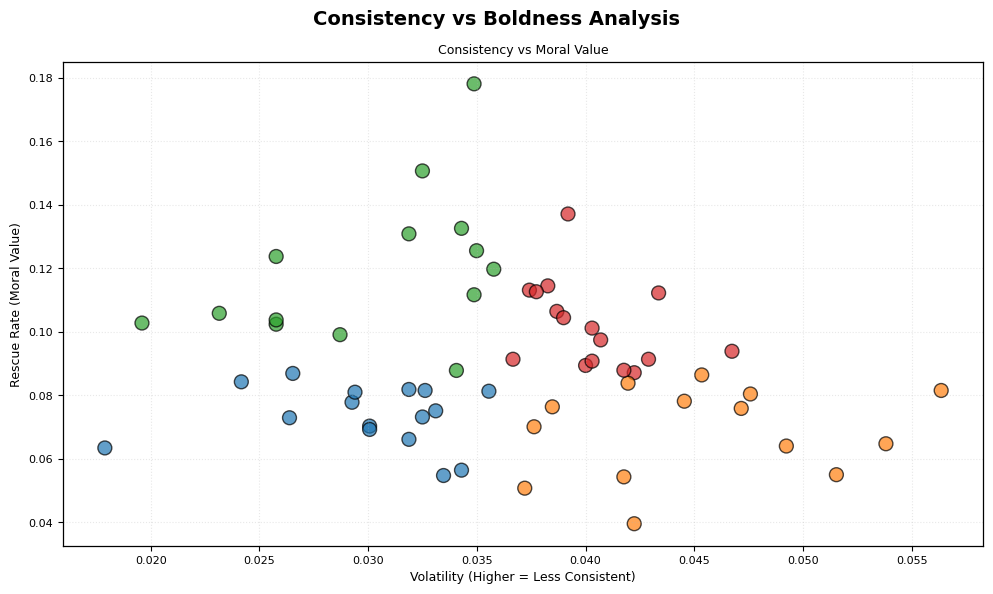

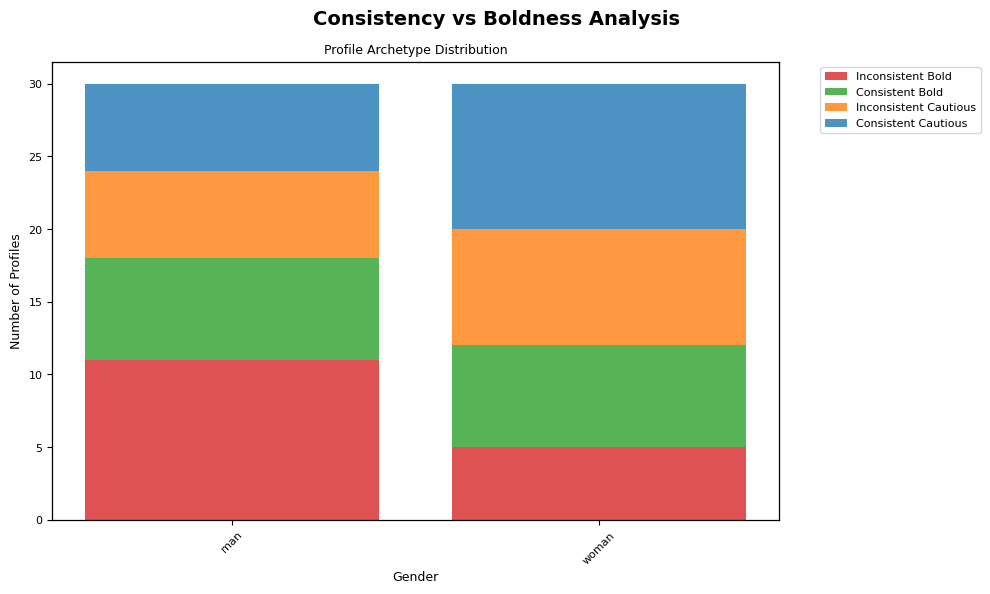

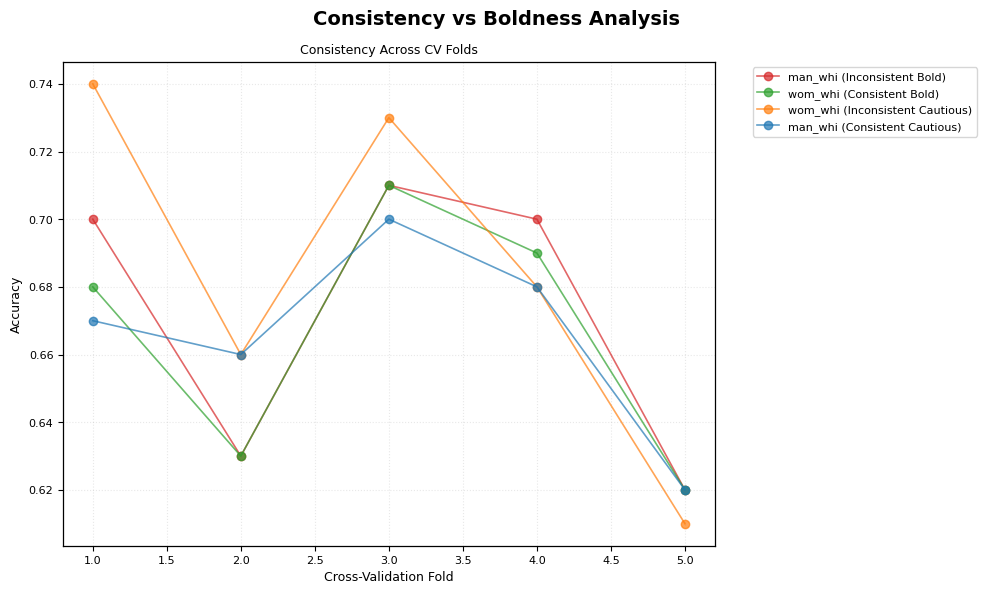

Consistency visualizations created successfully

=== Creating Causal Model Visualizations ===

TIER 3 THEORETICAL INTEGRATION

=== THEORETICAL INSIGHTS:
   - Consistent profiles match or outperform inconsistent ones in moral value
   - Implication: Consistency should be prioritized over boldness in AI systems
   - Evidence: Inconsistent rescue rate: 0.086 vs Consistent: 0.095
   - Strongest predictor of moral value (rescue): ethnicity_white
   - Strongest predictor of performance (accuracy): age_25
   - WARNING: Demographic traits strongly influence key outcomes
   - Bias assessment: 1 high, 1 moderate bias cases detected

THESIS-LEVEL CONCLUSIONS

METHODOLOGICAL ASSESSMENT
   - Data Quality: Good
   - Statistical Power: Adequate
   - Bias Detection Capability: Strong
   - Generalizability: Domain-specific
   - Profile coverage: 60 profiles
   - Trait coverage: 3 (gender, ethnicity, age)


/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:1463: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


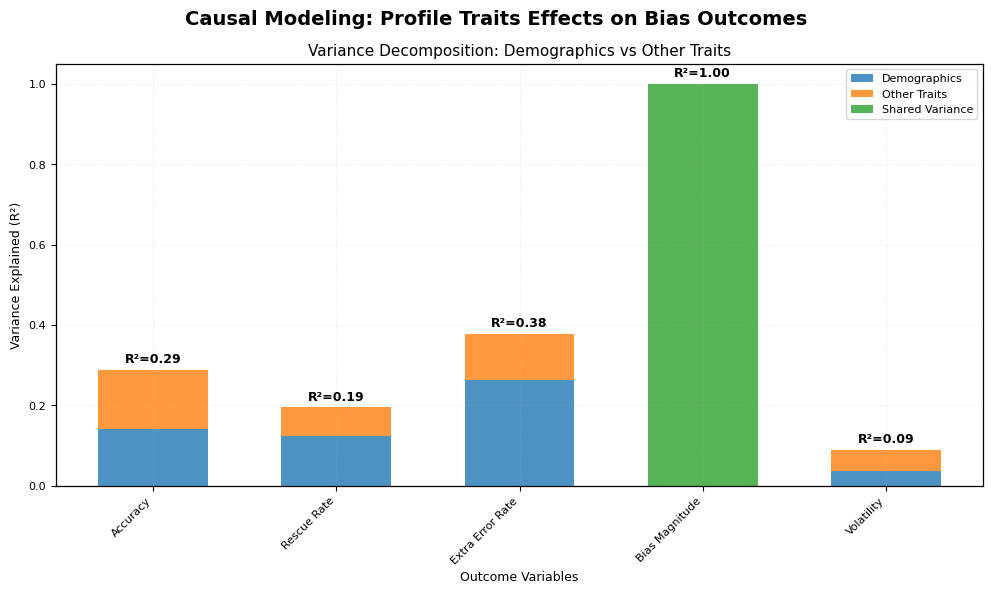

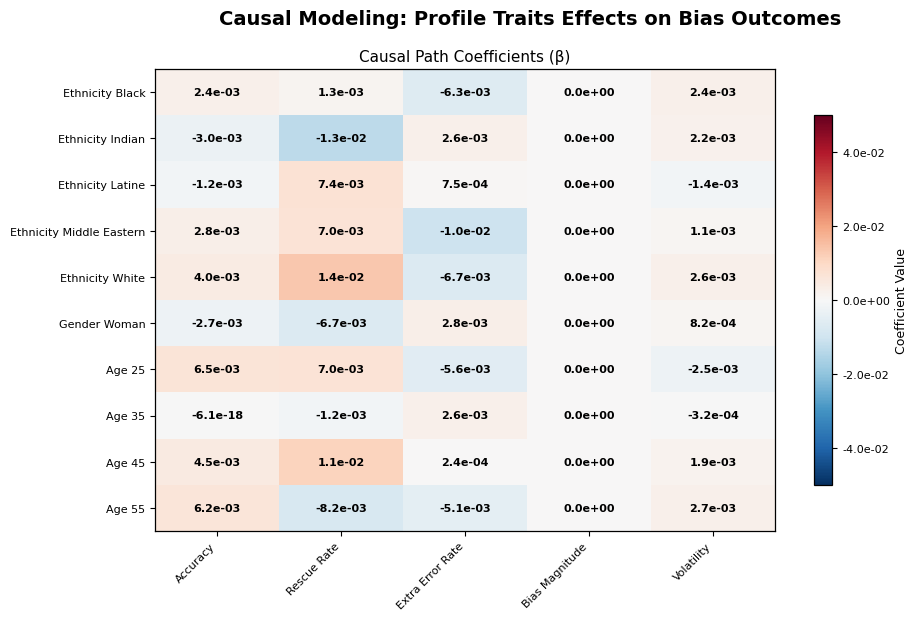

In [12]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS
from cases.manipulation_case import manipulation_case

result_tier3_few_shot = run_full_tier3_analysis(merged_df_few_shot, person_set=PERSON_ETHNICS, 
                                       case=manipulation_case,
                                       )

# Chain-of-Thoughts

In [13]:
from typing import Literal
from analysis_tools import (
    load_and_merge_profiles
    )
from cases.manipulation_case import manipulation_case


ALLOWED_MODELS = {"4o_mini", "4.1_mini"}

## Set the model you want to study here
model = "4.1_mini"

if model not in ALLOWED_MODELS:
    raise ValueError(f"Invalid model: {model}. Must be one of {ALLOWED_MODELS}")
if model == "4o_mini":
    model_foldername = "openai_4o_mini"
elif model == "4.1_mini":
    model_foldername = "openai_4.1_mini"

merged_df_cot = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/cot/classic/results_manipulation_optimized_cot.csv",
    role_playing_glob_pattern=f"results/{model_foldername}/cot/role_playing_ethnics/*/results_manipulation_optimized_cot.csv",
    sample_df=sample_mentalmanip,
    case=manipulation_case
)

=== Found 60 profile result files.
=== Merged DataFrame ready with columns:
 ['sample_id', 'true_label', 'base_pred', 'technique', 'vulnerability', 'profile1', 'profile2', 'profile3', 'profile4', 'profile5', 'profile6', 'profile7', 'profile8', 'profile9', 'profile10', 'profile11', 'profile12', 'profile13', 'profile14', 'profile15', 'profile16', 'profile17', 'profile18', 'profile19', 'profile20', 'profile21', 'profile22', 'profile23', 'profile24', 'profile25', 'profile26', 'profile27', 'profile28', 'profile29', 'profile30', 'profile31', 'profile32', 'profile33', 'profile34', 'profile35', 'profile36', 'profile37', 'profile38', 'profile39', 'profile40', 'profile41', 'profile42', 'profile43', 'profile44', 'profile45', 'profile46', 'profile47', 'profile48', 'profile49', 'profile50', 'profile51', 'profile52', 'profile53', 'profile54', 'profile55', 'profile56', 'profile57', 'profile58', 'profile59', 'profile60', 'prompt_tokens__base_pred', 'completion_tokens__base_pred', 'tokens_used__base_pr

Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')


=== DEMOGRAPHIC ACCURACY DIFFERENCES ===
[INFO] Profiles covered by metadata: 60/60

COMPREHENSIVE DEMOGRAPHIC ACCURACY DIFFERENCES ANALYSIS

EXECUTIVE SUMMARY
----------------------------------------
Total Comparisons Performed: 32
Significant Differences Found: 4
Statistical Significance Rate: 12.5%

LARGEST EFFECT SIZES
----------------------------------------
 1. age_age.age_1_vs_age.age_5          Effect Size: -2.231 (Large)
 2. age_age.age_4_vs_age.age_5          Effect Size: -1.579 (Large)
 3. age_age.age_2_vs_age.age_5          Effect Size: -1.565 (Large)
 4. age_age.age_1_vs_age.age_3          Effect Size: -1.020 (Large)
 5. age_age.age_3_vs_age.age_5          Effect Size: -0.879 (Large)

DETAILED SIGNIFICANT RESULTS
[NON-SIGNIFICANT]     men_vs_women                        | Man: 0.574 | Woman: 0.575
         Δ = -0.001 | p = 0.714 | d = -0.097

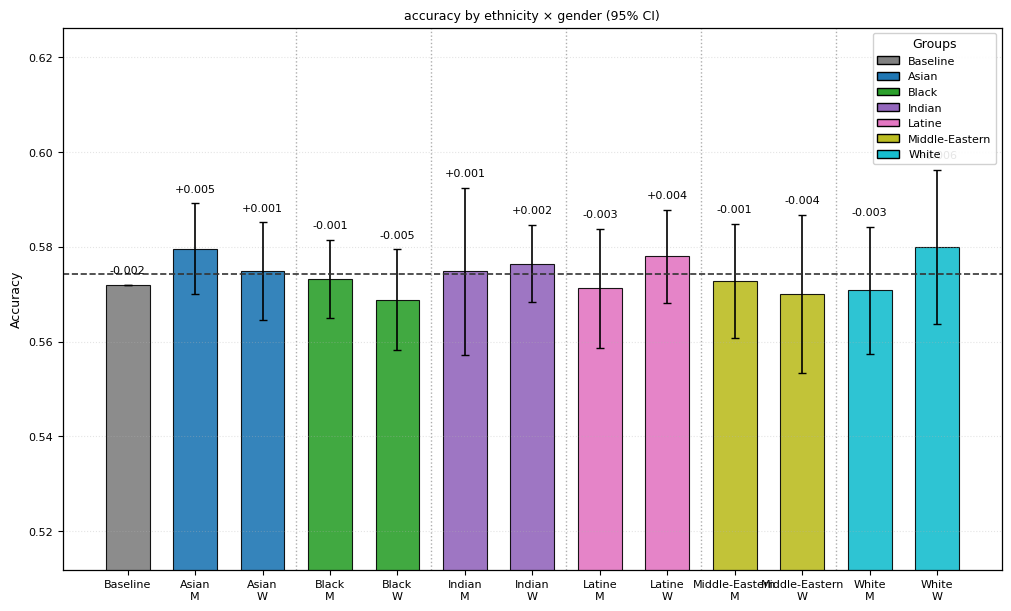

In [14]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS
from cases.manipulation_case import manipulation_case

results_cot = run_full_preliminary_analysis(merged_df_cot, case=manipulation_case, df=sample_mentalmanip, person_set=PERSON_ETHNICS)


COMPREHENSIVE TIER 1 BIAS ANALYSIS PIPELINE
Group keys: None
Dataset shape: (500, 309)
Auto-detecting available traits from PersonSet...
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')
Dataset shape: (500, 309)
Found category values in technique: ['Accusation', 'Accusation,Evasion', 'Accusation,Persuasion or Seduction', 'Accusation,Rationalization', 'Brandishing Anger', 'Brandishing Anger,Accusation', 'Brandishing Anger,Persuasion or Seduction', 'Denial', 'Denial,Accusation', 'Denial,Feigning Innocence', 'Evasion', 'Evasion,Accusation', 'Evasion,Intimidation', 'Feigning Innocence', 'Feigning Innocence,Evasion', 'Intimidation', 'Intimidation,Accusation', 'Intimidation,Brandishing Anger', 'Intimidation,Persuasion or Seduction', 'Persuasion or Seduction', 'Persuasion or Seduction,Accusation', 'Persuasion or Seduction,Intimidation', 'Persuasion or Seduction,Rationalization', 'Persuasion or Seduction,Shaming

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_1.py:685: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


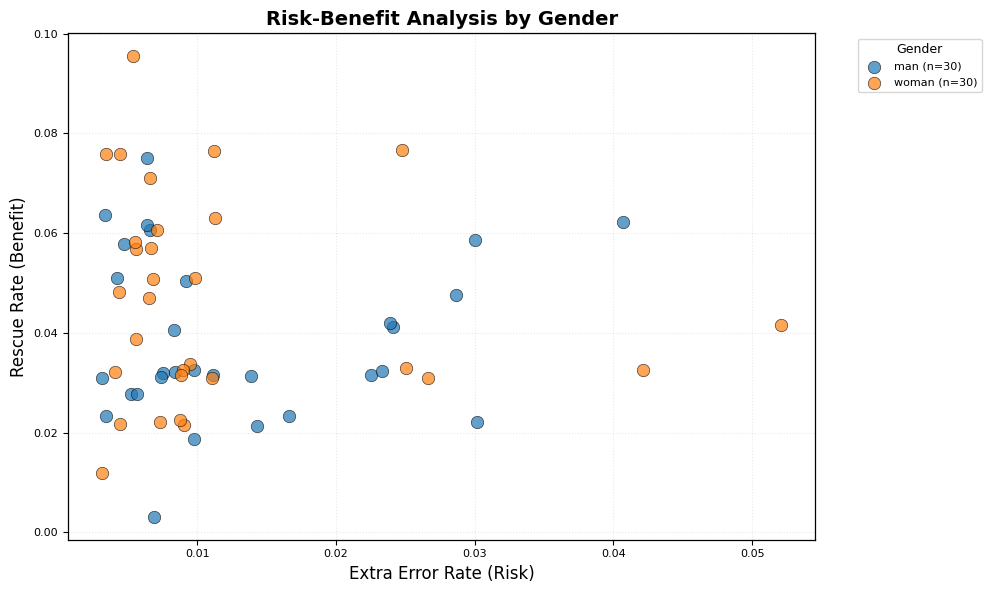


Creating risk-benefit plot for ethnicity...
  ethnicity levels: ['white', 'black', 'asian', 'latine', 'middle_eastern', 'indian']


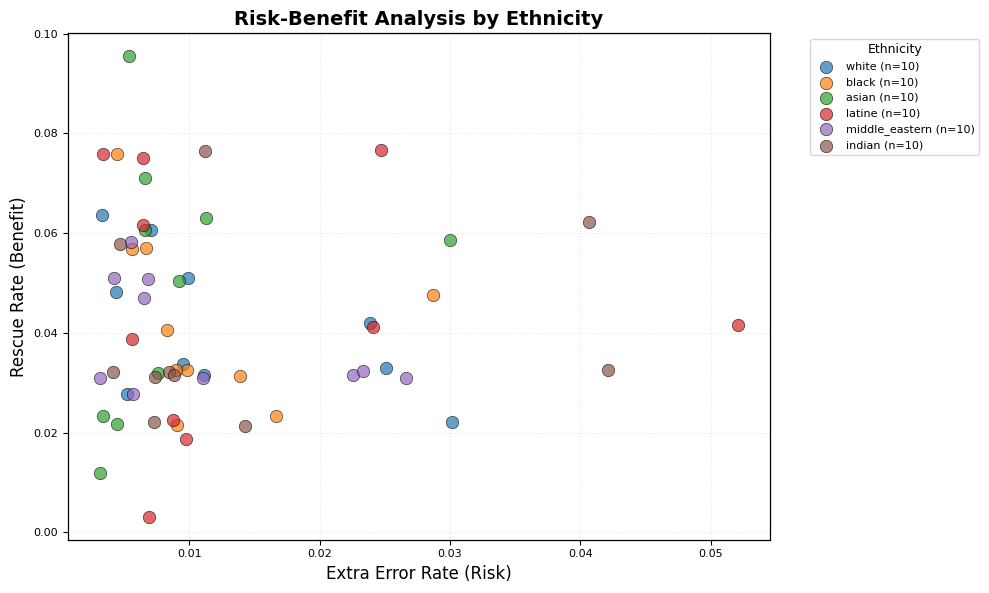

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_1.py:755: UserWarning: The figure layout has changed to tight
  plt.tight_layout()



Creating risk-benefit plot for age...

Creating Pareto frontier analysis...


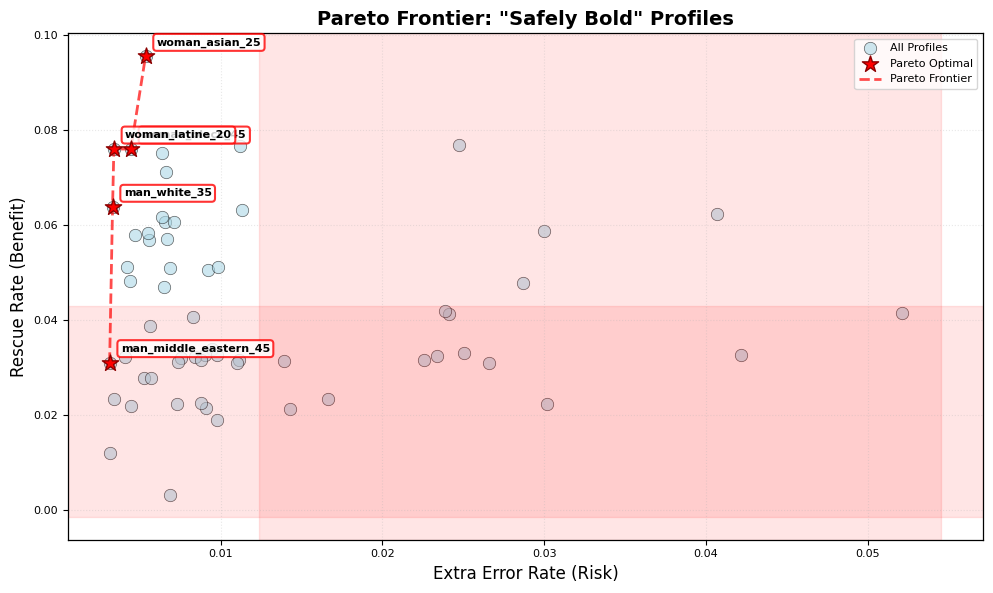


PARETO FRONTIER ANALYSIS RESULTS

Pareto Optimal Profiles (5 found):
  woman_black_45 (profile19)
    Rescue Rate: 0.076, Extra Error Rate: 0.004
    Total Rescued: 30, Total Extra Errors: 34
  woman_asian_25 (profile27)
    Rescue Rate: 0.095, Extra Error Rate: 0.005
    Total Rescued: 34, Total Extra Errors: 26
  man_white_35 (profile3)
    Rescue Rate: 0.064, Extra Error Rate: 0.003
    Total Rescued: 36, Total Extra Errors: 24
  woman_latine_20 (profile36)
    Rescue Rate: 0.076, Extra Error Rate: 0.003
    Total Rescued: 30, Total Extra Errors: 26
  man_middle_eastern_45 (profile44)
    Rescue Rate: 0.031, Extra Error Rate: 0.003
    Total Rescued: 26, Total Extra Errors: 24

Risk-Benefit Statistics:
  Total profiles analyzed: 60
  Average rescue rate: 0.043
  Average extra error rate: 0.012
  Best rescue rate: 0.095
  Lowest extra error rate: 0.003

Profile Archetypes:
  Safest Profile: woman_asian_55 (profile30)
    Extra Error Rate: 0.003
  Most Beneficial Profile: woman_asian

In [15]:
from analysis_1 import run_full_tier1_analysis

result_tier1_cot = run_full_tier1_analysis(merged_df_cot, case=manipulation_case, person_set=PERSON_ETHNICS)


EXECUTING COMPREHENSIVE TIER 2 ANALYSIS PIPELINE
Group keys: ('gender', 'ethnicity')
Dataset shape: (500, 309)
Category columns from CaseConfig: ['technique', 'vulnerability']
Using provided group keys: ('gender', 'ethnicity')
Dataset shape: (500, 309)

=== Running Step 1: Ensemble by Trait Analysis...
ENSEMBLE BY TRAIT ANALYSIS - PERSONSET VERSION
Group keys: ('gender', 'ethnicity')
Building trait groups with keys: ('gender', 'ethnicity')
Found 60 profile columns
Discovered trait values:
  gender: ['man', 'woman']
  ethnicity: ['asian', 'black', 'indian', 'latine', 'middle_eastern', 'white']
Created 12 trait groups:
  man_asian: 5 profiles
  man_black: 5 profiles
  man_indian: 5 profiles
  man_latine: 5 profiles
  man_middle_eastern: 5 profiles
  man_white: 5 profiles
  woman_asian: 5 profiles
  woman_black: 5 profiles
  woman_indian: 5 profiles
  woman_latine: 5 profiles
  woman_middle_eastern: 5 profiles
  woman_white: 5 profiles
Baseline accuracy: 0.5720

Ensemble Performance by Tr

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_2.py:1173: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


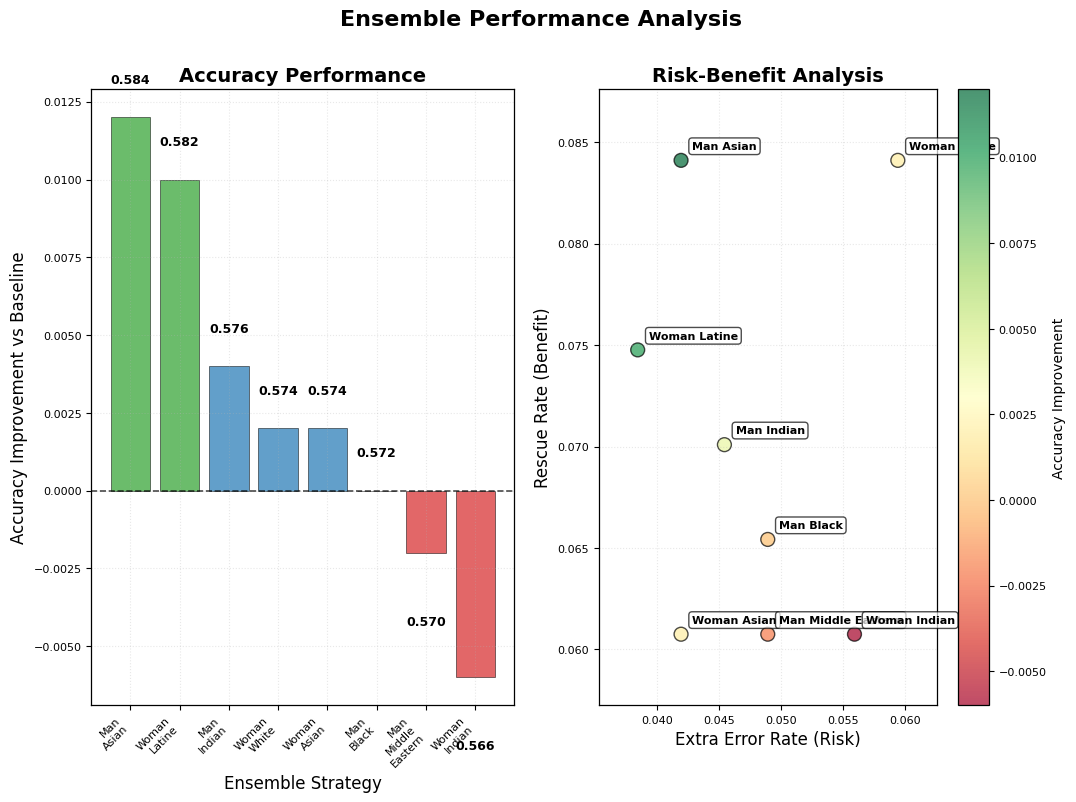

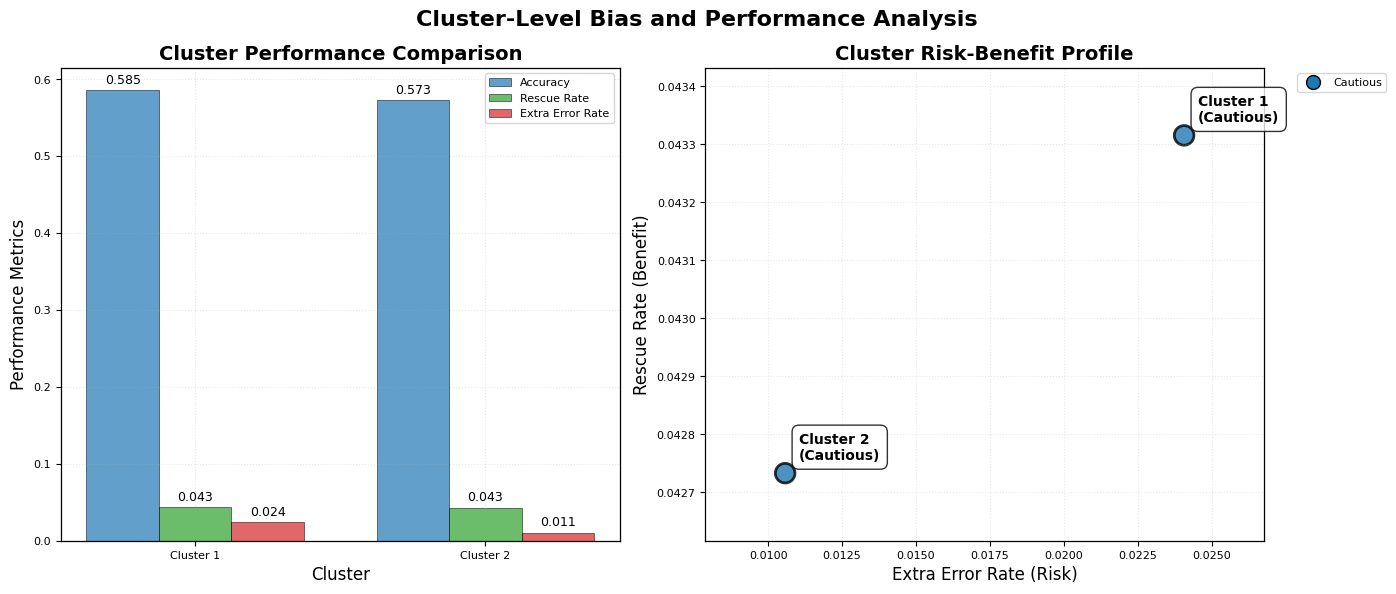

4. System-Level Recommendations...


/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_2.py:1383: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


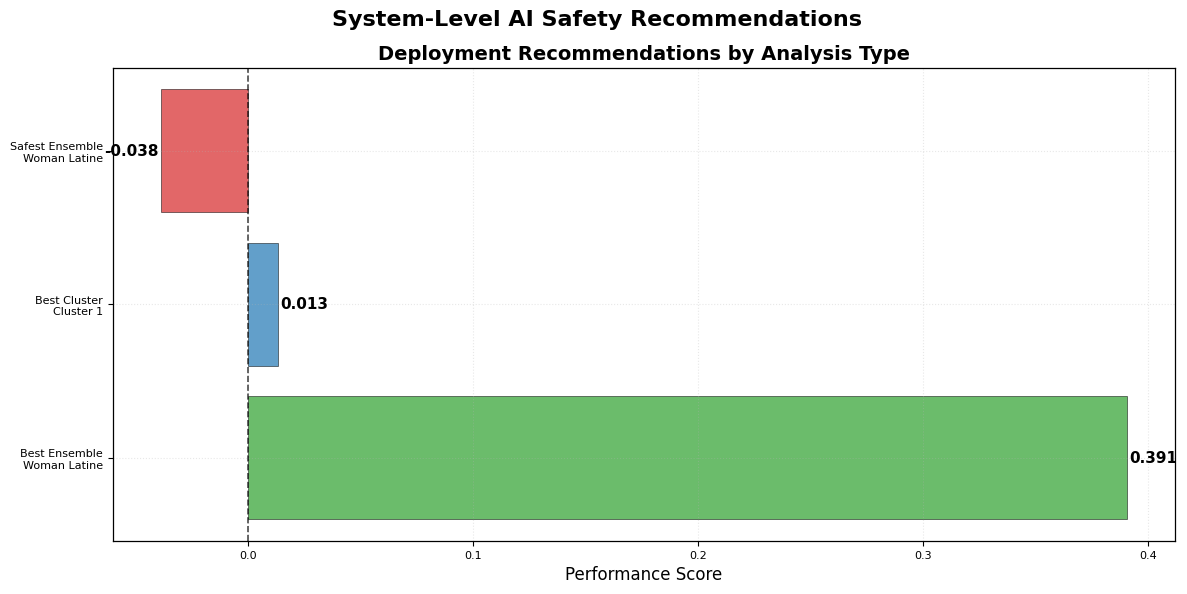


Completed! Created 2 visualizations.
SUCCESS: Visualizations created successfully

COMPREHENSIVE TIER 2 EXECUTIVE SUMMARY
   • Best Overall Ensemble: woman_latine
   • Best Cluster: cluster_1
   • Cognitive style analysis skipped: No cognitive style data found


In [16]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS

results_tier2_cot = run_full_tier2_analysis(
    merged_df=merged_df_cot,
    person_set=PERSON_ETHNICS,
    case=manipulation_case,
    group_keys=("gender", "ethnicity"))


EXECUTING TIER 3 ANALYSIS PIPELINE
Auto-detecting available traits from PersonSet...
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')
Cross-validation folds: 5

=== Running Consistency vs Boldness Analysis ===
CONSISTENCY vs BOLDNESS TRADEOFF ANALYSIS
Group keys for analysis: ('gender', 'ethnicity', 'age')
Found 60 valid profiles out of 60 total profile columns
=== Calculating consistency across 5 folds...
=== Calculating boldness metrics...
Found category values in technique: ['Accusation', 'Accusation,Evasion', 'Accusation,Persuasion or Seduction', 'Accusation,Rationalization', 'Brandishing Anger', 'Brandishing Anger,Accusation', 'Brandishing Anger,Persuasion or Seduction', 'Denial', 'Denial,Accusation', 'Denial,Feigning Innocence', 'Evasion', 'Evasion,Accusation', 'Evasion,Intimidation', 'Feigning Innocence', 'Feigning Innocence,Evasion', 'Intimidation', 'Intimidation,Accusation', 'Intimidation,Brandi

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:657: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:674: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:714: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:745: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


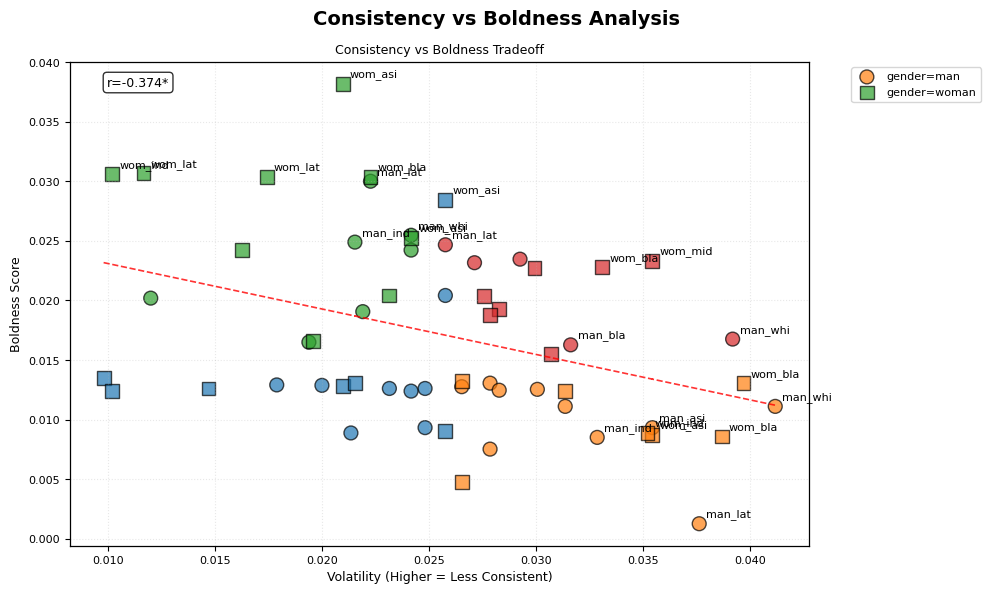

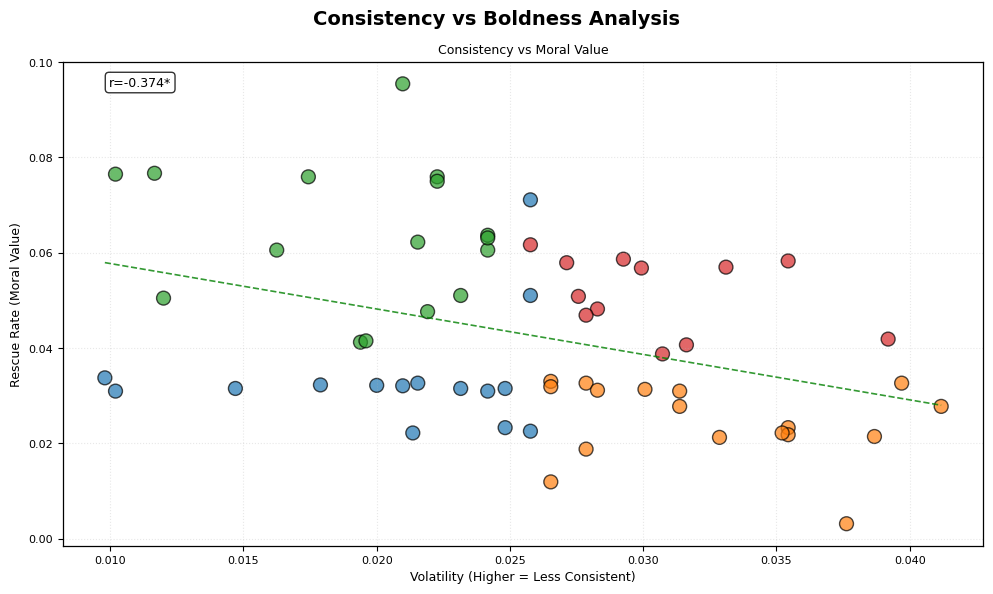

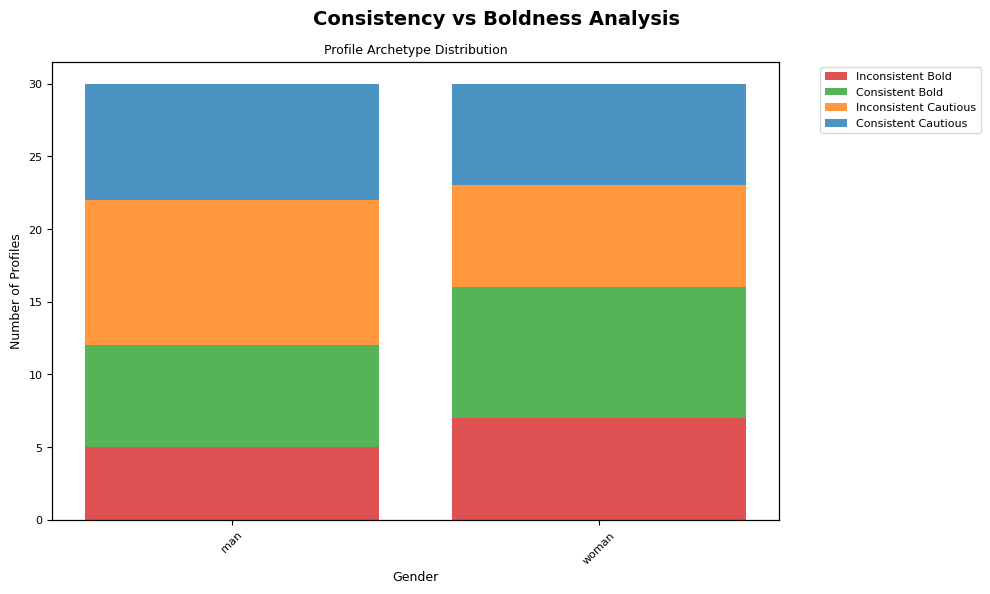

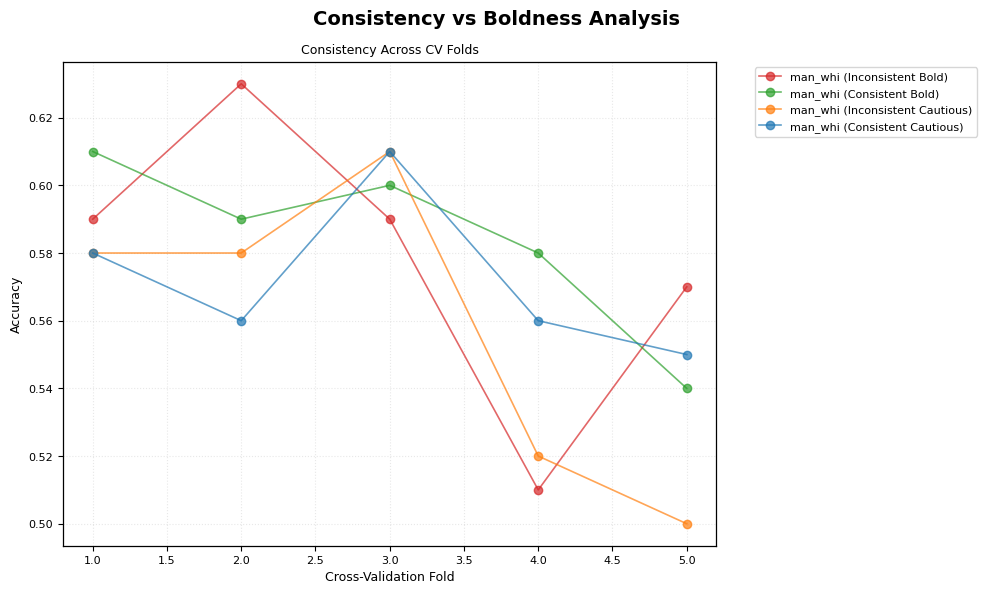

Consistency visualizations created successfully

=== Creating Causal Model Visualizations ===

TIER 3 THEORETICAL INTEGRATION

=== THEORETICAL INSIGHTS:
   - Consistent profiles match or outperform inconsistent ones in moral value
   - Implication: Consistency should be prioritized over boldness in AI systems
   - Evidence: Inconsistent rescue rate: 0.036 vs Consistent: 0.049
   - Strongest predictor of moral value (rescue): age_35
   - Strongest predictor of performance (accuracy): age_55
   - Bias assessment: 1 high, 1 moderate bias cases detected

THESIS-LEVEL CONCLUSIONS

METHODOLOGICAL ASSESSMENT
   - Data Quality: Good
   - Statistical Power: Adequate
   - Bias Detection Capability: Strong
   - Generalizability: Domain-specific
   - Profile coverage: 60 profiles
   - Trait coverage: 3 (gender, ethnicity, age)


/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:1463: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


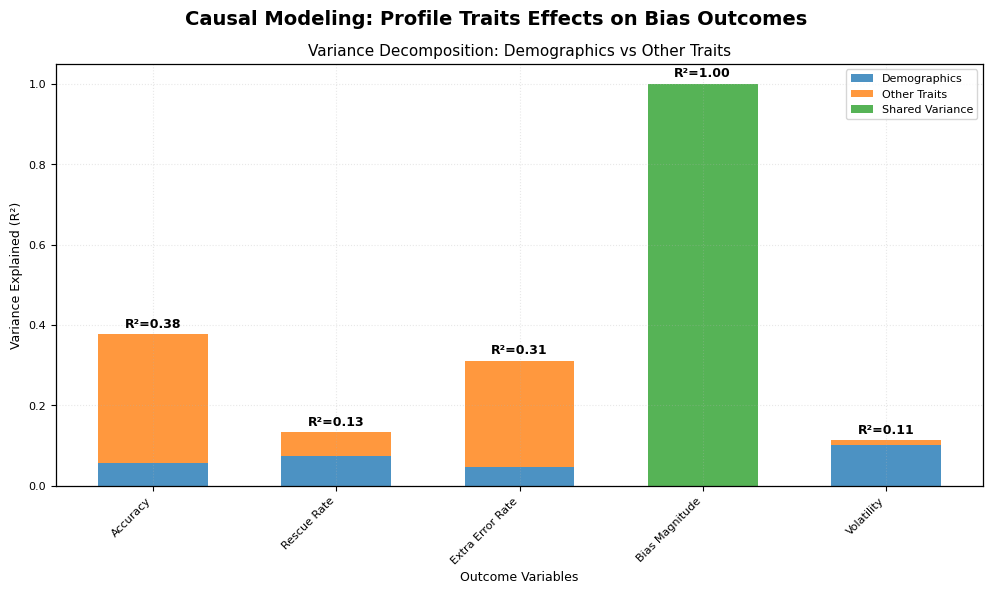

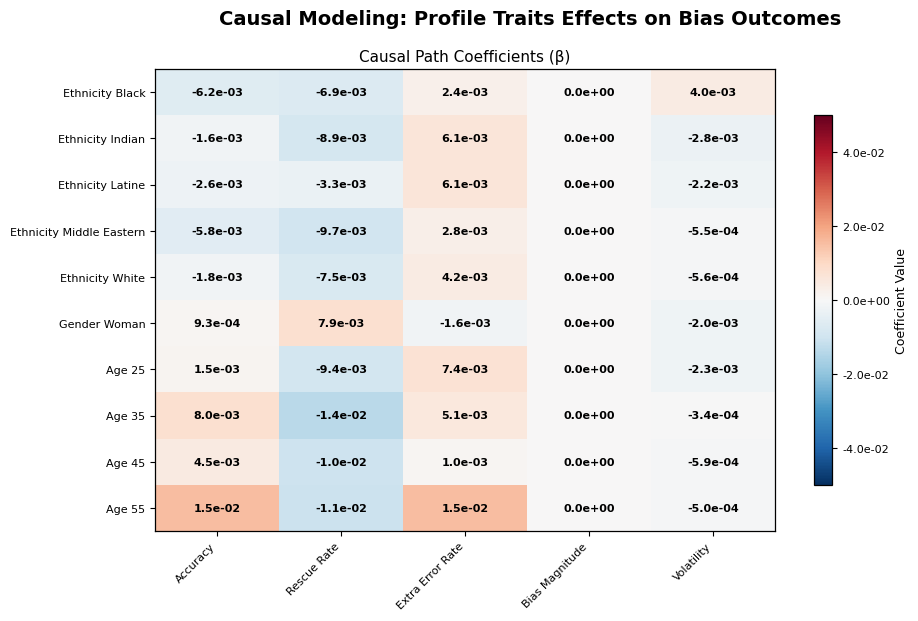

In [17]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS
from cases.manipulation_case import manipulation_case

result_tier3_cot = run_full_tier3_analysis(merged_df_cot, person_set=PERSON_ETHNICS, case=manipulation_case)
